In [3]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from skimage.feature import canny
from skimage.transform import hough_line, hough_line_peaks
from PIL import Image, ImageDraw

# 1. データの読み込みと処理 (前回の内容と同様)
df = pd.read_csv(r"E:\refit\all_roi_spectra.csv")
start_band_name = "wave_1025.91nm"
end_band_name = "wave_1238.24nm"

try:
    start_idx = df.columns.get_loc(start_band_name)
    end_idx = df.columns.get_loc(end_band_name)
except:
    start_idx, end_idx = 2, len(df.columns) - 1

spectral_data = df.iloc[:, start_idx : end_idx + 1].values

pca = PCA(n_components=3)
pc3_flat = pca.fit_transform(spectral_data)[:, 2]

min_y, max_y = df['y'].min(), df['y'].max()
min_x, max_x = df['x'].min(), df['x'].max()
height = max_y - min_y + 1
width = max_x - min_x + 1

pc3_image = np.zeros((height, width))
for idx, row in df.iterrows():
    pc3_image[int(row['y'])-min_y, int(row['x'])-min_x] = pc3_flat[idx]

pc3_norm = (pc3_image - pc3_image.min()) / (pc3_image.max() - pc3_image.min())

# 2. マスク画像の生成
edges = canny(pc3_norm, sigma=1.5)
tested_angles = np.linspace(-np.pi / 2, np.pi / 2, 360, endpoint=False)
h, theta, d = hough_line(edges, theta=tested_angles)
accum, angles, dists = hough_line_peaks(h, theta, d, num_peaks=1)

mask_img = Image.new("L", (width, height), 0)
draw = ImageDraw.Draw(mask_img)

if len(angles) > 0:
    angle = angles[0]
    dist = dists[0]
    points = []
    
    if abs(np.sin(angle)) > 1e-5:
        y = dist / np.sin(angle)
        if 0 <= y <= height: points.append((0, y))
        y = (dist - width * np.cos(angle)) / np.sin(angle)
        if 0 <= y <= height: points.append((width, y))
    if abs(np.cos(angle)) > 1e-5:
        x = dist / np.cos(angle)
        if 0 <= x <= width: points.append((x, 0))
        x = (dist - height * np.sin(angle)) / np.cos(angle)
        if 0 <= x <= width: points.append((x, height))
            
    unique_points = []
    for p in points:
        if not any(np.allclose(p, up, atol=1e-1) for up in unique_points):
            unique_points.append(p)
            
    if len(unique_points) >= 2:
        unique_points.sort(key=lambda p: p[0])
        draw.line([unique_points[0], unique_points[-1]], fill=1, width=3)

mask_array = np.array(mask_img)

# 3. グリッド形式のCSV出力
df_grid = pd.DataFrame(mask_array)
# ヘッダーとインデックスなしで保存することで、純粋な行列データにする
df_grid.to_csv('line_mask_grid.csv', index=False, header=False)

ERROR! Session/line number was not unique in database. History logging moved to new session 545


In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from skimage.feature import canny
from skimage.transform import hough_line, hough_line_peaks
from PIL import Image, ImageDraw

# =====================
# 設定ここだけ変える
# =====================
input_csv = r"E:\refit\all_map_spectra.csv"

center = np.array([1065, 1463])   # (y, x)
R_BIG   = 100                     # まずこの範囲(±100)で処理
R_SAVE  = 40                      # 最後にこの範囲(±40)だけ保存

start_band_name = "wave_1025.91nm"
end_band_name   = "wave_1238.24nm"

out_csv = "line_mask_gridp.csv"

# =====================
# 0) 必要列だけ読む（軽量化）
# =====================
cols = pd.read_csv(input_csv, nrows=0).columns.tolist()

if start_band_name in cols and end_band_name in cols:
    s = cols.index(start_band_name)
    e = cols.index(end_band_name)
    usecols = ["y", "x"] + cols[s:e+1]
else:
    # フォールバック：先頭2列が y,x で残りがスペクトル想定
    usecols = cols

df = pd.read_csv(input_csv, usecols=usecols)

# =====================
# 1) center±100 のデータだけ抽出（= img_slice 相当）
#    numpyスライスに合わせて end は「未満」にしています
# =====================
y0_big, y1_big = int(center[0] - R_BIG), int(center[0] + R_BIG)
x0_big, x1_big = int(center[1] - R_BIG), int(center[1] + R_BIG)

df_big = df[
    (df["y"] >= y0_big) & (df["y"] < y1_big) &
    (df["x"] >= x0_big) & (df["x"] < x1_big)
].copy()

height_big = y1_big - y0_big  # = 2*R_BIG
width_big  = x1_big - x0_big  # = 2*R_BIG

# =====================
# 2) PCA(3成分) → PC3画像生成
# =====================
cols_big = df_big.columns.tolist()
try:
    start_idx = cols_big.index(start_band_name)
    end_idx   = cols_big.index(end_band_name)
except ValueError:
    start_idx, end_idx = 2, len(cols_big) - 1

spectral_data = df_big.iloc[:, start_idx:end_idx+1].to_numpy()

pca = PCA(n_components=3)
pc3_flat = pca.fit_transform(spectral_data)[:, 2]

pc3_image = np.full((height_big, width_big), np.nan, dtype=np.float32)

yy = (df_big["y"].to_numpy().astype(int) - y0_big)
xx = (df_big["x"].to_numpy().astype(int) - x0_big)
pc3_image[yy, xx] = pc3_flat.astype(np.float32)

# 欠損があれば平均で埋める（Canny用）
if np.isnan(pc3_image).any():
    fill = np.nanmean(pc3_image)
    pc3_image = np.where(np.isnan(pc3_image), fill, pc3_image)

mn, mx = pc3_image.min(), pc3_image.max()
pc3_norm = (pc3_image - mn) / (mx - mn + 1e-12)

# =====================
# 3) エッジ→Hough→直線マスク生成（200x200上で）
# =====================
edges = canny(pc3_norm, sigma=1.5)
tested_angles = np.linspace(-np.pi / 2, np.pi / 2, 360, endpoint=False)
h, theta, d = hough_line(edges, theta=tested_angles)
accum, angles, dists = hough_line_peaks(h, theta, d, num_peaks=1)

mask_img = Image.new("L", (width_big, height_big), 0)
draw = ImageDraw.Draw(mask_img)

if len(angles) > 0:
    angle = float(angles[0])
    dist  = float(dists[0])
    points = []

    if abs(np.sin(angle)) > 1e-5:
        y = dist / np.sin(angle)
        if 0 <= y <= height_big: points.append((0, y))
        y = (dist - width_big * np.cos(angle)) / np.sin(angle)
        if 0 <= y <= height_big: points.append((width_big, y))

    if abs(np.cos(angle)) > 1e-5:
        x = dist / np.cos(angle)
        if 0 <= x <= width_big: points.append((x, 0))
        x = (dist - height_big * np.sin(angle)) / np.cos(angle)
        if 0 <= x <= width_big: points.append((x, height_big))

    unique_points = []
    for p in points:
        if not any(np.allclose(p, up, atol=1e-1) for up in unique_points):
            unique_points.append(p)

    if len(unique_points) >= 2:
        unique_points.sort(key=lambda p: p[0])
        draw.line([unique_points[0], unique_points[-1]], fill=1, width=3)

mask_array_big = np.array(mask_img, dtype=np.uint8)

# =====================
# 4) そのうち center±40 の範囲だけ切り出して保存（80x80）
# =====================
offset = R_BIG - R_SAVE
y0, y1 = offset, offset + 2 * R_SAVE
x0, x1 = offset, offset + 2 * R_SAVE

mask_small = mask_array_big[y0:y1, x0:x1]

pd.DataFrame(mask_small).to_csv(out_csv, index=False, header=False)
print(f"saved: {out_csv}  shape={mask_small.shape}")


saved: line_mask_gridp.csv  shape=(80, 80)


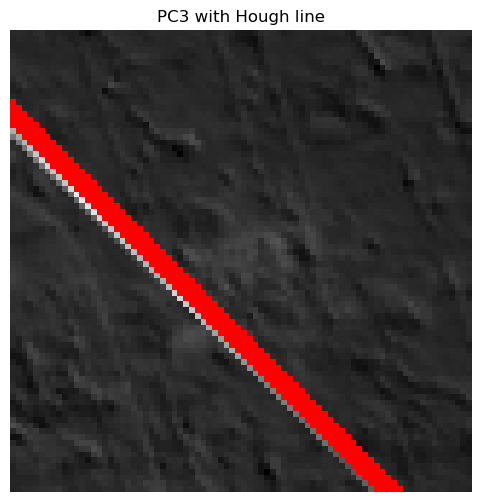

In [4]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. 元データの読み込みとPC3画像の生成
start_band_name = "wave_1025.91nm"
end_band_name = "wave_1238.24nm"

try:
    start_idx = df.columns.get_loc(start_band_name)
    end_idx = df.columns.get_loc(end_band_name)
except:
    start_idx, end_idx = 2, len(df.columns) - 1

spectral_data = df.iloc[:, start_idx : end_idx + 1].values
pca = PCA(n_components=3)
pc3_flat = pca.fit_transform(spectral_data)[:, 2]

min_y, max_y = df['y'].min(), df['y'].max()
min_x, max_x = df['x'].min(), df['x'].max()
height = max_y - min_y + 1
width = max_x - min_x + 1

pc3_image = np.zeros((height, width))
for idx, row in df.iterrows():
    pc3_image[int(row['y'])-min_y, int(row['x'])-min_x] = pc3_flat[idx]

# 2. グリッドCSVの読み込み
# Excel上の配置と画像の画素位置が対応したCSVファイルを想定
# ヘッダーなし、インデックスなし
grid_filename = r"E:\tools\thesis\line_mask_gridp.csv"
try:
    df_grid = pd.read_csv(grid_filename, header=None)
    grid_mask = df_grid.values
except FileNotFoundError:
    print("CSVファイルが見つかりません。")
    grid_mask = np.zeros((height, width))

# 3. 画像への赤線描画
pc3_norm = (pc3_image - pc3_image.min()) / (pc3_image.max() - pc3_image.min())
img_rgb = np.stack([pc3_norm]*3, axis=-1)

# マスクが1 (または0より大きい) の場所を赤にする
if grid_mask.shape == (height, width):
    mask_bool = grid_mask > 0
    img_rgb[mask_bool] = [1.0, 0.0, 0.0] # 赤色
else:
    print(f"CSVのサイズ {grid_mask.shape} が画像サイズ {(height, width)} と一致しません。")

# 4. 保存と表示
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title("PC3 with Hough line")
plt.axis('off')
plt.savefig('pc3_from_grid_csv.png')
plt.show()

Loading Data...
LUT Loaded: (22, 2121)
Simulation Targets (ppm): [0.5, 1.0, 2.0, 3.0, 4.0, 5.0]
Target SNR: 450

Starting Simulation Loop...


Testing Concentrations:   0%|          | 0/6 [00:00<?, ?it/s]

Testing Concentrations: 100%|██████████| 6/6 [01:38<00:00, 16.37s/it]


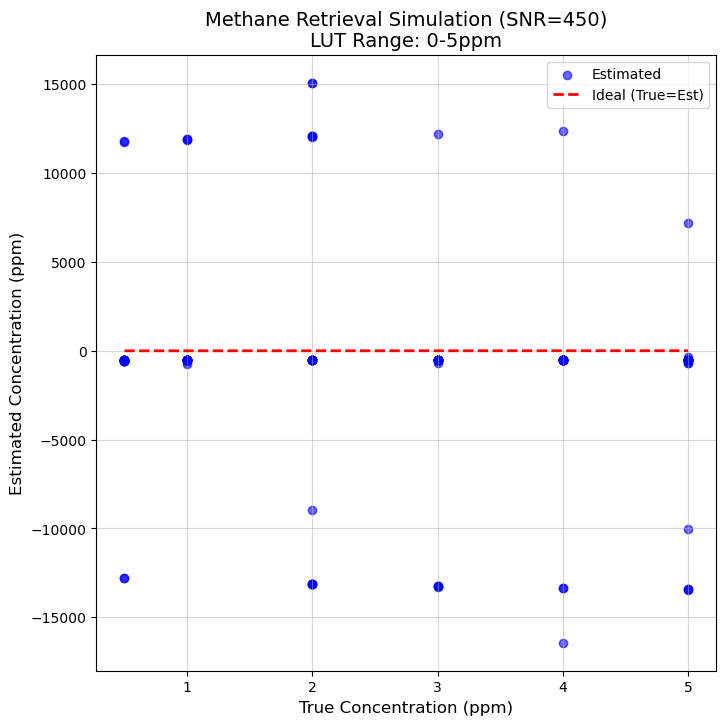

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from tqdm import tqdm  # 進行状況表示用

# =========================================================
# 1. 設定 & 定数
# =========================================================
LUT_FILE = r"E:\refit\water_lut\2.0.csv"            # メタンLUT (0~5ppm, 0.25刻み)
HISUI_FILE = r"E:\新しいフォルダー\pixel_1000_1000.csv" # HISUIの波長情報を含むファイル
SNR = 450                        # 1600nm帯の想定S/N比
TRIALS = 20                      # 各濃度ごとの試行回数（ノイズのパターンを変えて試す回数）

# シミュレーションでテストする「正解」メタン濃度のリスト
# 2.0.csvの範囲(0~5ppm)内で設定します
TRUE_CONCENTRATIONS = [0.5, 1.0, 2.0, 3.0, 4.0, 5.0] 

hi_i = 110
hi_f = 121
mo_i = 1800
mo_f = 2121

# =========================================================
# 2. ユーザー提供の関数群 (抽出・適合)
# =========================================================

def extract_ch4(data):
    if data.ndim != 2 or mo_f > data.shape[1] or mo_i < 0:
        raise ValueError("Invalid shape or indices for extract_ch4")
    return data[:, mo_i:mo_f]

def instrumental_function(data, sigma, mu):
    # ユーザー提供の装置関数畳み込み処理
    wavelengths = data[0, :]
    num_levels = data.shape[0] - 1
    out = np.zeros_like(data)
    out[0, :] = wavelengths
    ave_wave = np.mean(wavelengths)
    sigma = max(sigma, 1e-6)
    
    # ガウシアンカーネルの作成と畳み込み
    gauss = np.exp(-(wavelengths - ave_wave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
    for i in range(1, num_levels + 1):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode='same')
    return out

def reflectance_correction(data, a, b, k):
    data_corrected = data.copy()
    wavelengths = data_corrected[0, :]
    num_levels = data_corrected.shape[0] - 1
    for i in range(1, num_levels + 1):
        reflectance_factor = a + b * wavelengths
        reflectance_factor = np.maximum(reflectance_factor, 0)
        data_corrected[i, :] = data_corrected[i, :] * reflectance_factor + k
    return data_corrected

def estimated_by_ch4(data, c):
    # LUTの濃度間を補間して、指定濃度cのスペクトルを作成する関数
    num_levels = data.shape[0] - 1
    # 2.0.csv は 0, 0.25, 0.5... という刻みなのでそれに合わせる
    ch4_levels = np.arange(0, 0.25 * num_levels, 0.25) 

    if c <= ch4_levels[0]: position = 1
    elif c >= ch4_levels[-1]: position = len(ch4_levels) - 1
    else: position = np.searchsorted(ch4_levels, c)

    idx_lower, idx_upper = position, position + 1
    if idx_upper >= data.shape[0]:
        idx_upper = idx_lower = data.shape[0] - 1
    elif idx_lower < 1:
        idx_lower = 1
        idx_upper = idx_lower

    level_lower = ch4_levels[position-1]
    level_upper = ch4_levels[position] # 修正: positionそのものがupper側のインデックスに対応
    
    level_step = level_upper - level_lower
    r = (c - level_lower) / level_step if level_step > 0 else 0.0
    
    interpolated_values = (1 - r) * data[idx_lower, :] + r * data[idx_upper, :]
    return interpolated_values.tolist()

def wavelength_adjustment_ch4(data_ch4_interpolated, modtran_wavelengths, data_hisui):
    # MODTRANの波長をHISUIの波長に合わせてリサンプリング
    if len(modtran_wavelengths) < 2: return []
    data_ch4_arr = np.asarray(data_ch4_interpolated)
    
    out = []
    for i in range(hi_i, hi_f):
        hisui_wave = data_hisui.iloc[i, 0] # Wavelength column assumed at index 0
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        
        if position == 0: out.append(data_ch4_arr[0])
        elif position >= len(modtran_wavelengths): out.append(data_ch4_arr[-1])
        else:
            # Linear interpolation
            w_low = modtran_wavelengths[position - 1]
            w_high = modtran_wavelengths[position]
            r = (hisui_wave - w_low) / (w_high - w_low)
            val = (1 - r) * data_ch4_arr[position - 1] + r * data_ch4_arr[position]
            out.append(val)
    return out

def func_ch4(data, data_hisui, sigma, mu, a, b, c, k):
    # 前向きモデル関数：パラメータからスペクトルを合成
    out = instrumental_function(data, sigma, mu)
    out_extracted = extract_ch4(out)
    wavelengths_ch4_range = out_extracted[0, :]
    out_reflectance_corrected = reflectance_correction(out_extracted.copy(), a, b, k)
    out_estimated = estimated_by_ch4(out_reflectance_corrected, c)
    out_adjusted = wavelength_adjustment_ch4(out_estimated, wavelengths_ch4_range, data_hisui)
    return out_adjusted

def residuals_ch4(param, data, data_hisui, observed_spectrum):
    # 残差関数
    sigma, mu, a, b, c, k = param
    try:
        w_est = func_ch4(data, data_hisui, sigma, mu, a, b, c, k)
        w_est_np = np.asarray(w_est)
        # 観測データとの差分を返す
        return observed_spectrum - w_est_np
    except Exception:
        return np.full_like(observed_spectrum, 1e6)

def estimate_param_ch4_init(data_adjusted, data_hisui):
    # 初期パラメータ推定用（簡易版）
    # data_adjusted: 1.8ppmなどで計算済みのMODTRANスペクトル(HISUI波長)
    obs_rad = data_hisui.iloc[hi_i:hi_f, 1].values
    obs_wave = data_hisui.iloc[hi_i:hi_f, 0].values
    
    if len(data_adjusted) != len(obs_rad): return 0.0, 0.0
    
    max_ref = np.max(obs_rad)
    rel_max_index = np.argmax(obs_rad)
    max_wave = obs_wave[rel_max_index]
    modtran_val_at_max = data_adjusted[rel_max_index]
    
    if max_wave == 0 or modtran_val_at_max == 0: return 0.0, 0.0
    
    b = max_ref / max_wave / modtran_val_at_max
    a = 0.0
    return b, a

# =========================================================
# 3. メイン処理 (データ読み込み & シミュレーション)
# =========================================================

# --- データの読み込み ---
print("Loading Data...")
# LUT読み込み
df_lut = pd.read_csv(LUT_FILE)
data_ch4_raw = df_lut.to_numpy()
data_ch4_np = data_ch4_raw.T.astype(float) # 転置して (行:濃度, 列:波長) の形に
# ユーザーコードにあるスケーリング処理を適用
data_ch4_np[1:, :] = data_ch4_np[1:, :] * 100 

# HISUI波長データ読み込み
df_pixel = pd.read_csv(HISUI_FILE)
# ユーザーコードが期待するカラム名 (Wavelength, Radiance) に合わせるためのダミーDF作成
data_hisui_template = df_pixel.iloc[:, [0, 1]].copy()
data_hisui_template.columns = ["Wavelength", "Radiance"]
# 波長データのみ使用するのでRadianceの中身はこの時点では何でも良い

print(f"LUT Loaded: {data_ch4_np.shape}")
print(f"Simulation Targets (ppm): {TRUE_CONCENTRATIONS}")
print(f"Target SNR: {SNR}")

results_true = []
results_est = []

print("\nStarting Simulation Loop...")

# --- シミュレーションループ ---
for true_conc in tqdm(TRUE_CONCENTRATIONS, desc="Testing Concentrations"):
    
    # 1. 「正解」スペクトルの作成 (ノイズなし)
    # シミュレーション用の「真のパラメータ」を設定
    true_sigma = 8
    true_mu = 2.0
    true_a = 0.3
    true_b = 0.0 # LUTが既にスケールされていると仮定
    true_k = 0.04
    
    # func_ch4を使って「真のスペクトル」を合成
    # (ここでinstrumental_functionが走るため少し時間がかかります)
    true_spectrum_list = func_ch4(
        data_ch4_np, data_hisui_template, 
        true_sigma, true_mu, true_a, true_b, true_conc, true_k
    )
    true_spectrum = np.array(true_spectrum_list)
    
    # 2. ノイズ付加とリトリーバルを繰り返す
    for _ in range(TRIALS):
        # --- ノイズ生成 ---
        # 信号量に応じたガウシアンノイズ (Std = Signal / SNR)
        noise_std = true_spectrum / SNR
        noise = np.random.normal(0, noise_std, size=len(true_spectrum))
        
        observed_spectrum = true_spectrum + noise
        
        # --- リトリーバル実行 ---
        # HISUIデータフレームのRadiance部分を、今回の「擬似観測データ」に書き換え
        # (estimate_param_ch4などで参照されるため)
        data_hisui_current = data_hisui_template.copy()
        # ilocで該当バンドのRadianceを更新
        data_hisui_current.iloc[hi_i:hi_f, 1] = observed_spectrum
        
        # 初期値の推定 (ユーザーコードの流れを模倣)
        # まず仮のsigma=6.5, c=1.8でスペクトルを作り、a, bの初期値を決める
        temp_spec = func_ch4(data_ch4_np, data_hisui_current, 6.5, 0.0, 0.0, 1.0, 1.8, 0.0)
        b_init, a_init = estimate_param_ch4_init(temp_spec, data_hisui_current)
        
        # LM法の初期パラメータ [sigma, mu, a, b, c, k]
        # c(濃度)の初期値は 1.8ppm スタート
        x0 = [6.5, 0.0, a_init, b_init, 1.8, 0.0]
        
        try:
            # least_squares実行
            # residuals_ch4の引数として observed_spectrum を渡す形に変更しています
            res = least_squares(
                residuals_ch4, x0, 
                args=(data_ch4_np, data_hisui_template, observed_spectrum),
                method='lm'
            )
            
            estimated_conc = res.x[4] # パラメータの5番目が濃度
            
            # 結果保存
            results_true.append(true_conc)
            results_est.append(estimated_conc)
            
        except Exception as e:
            print(f"Error in retrieval: {e}")

# =========================================================
# 4. 結果の可視化
# =========================================================
plt.figure(figsize=(8, 8))
plt.scatter(results_true, results_est, alpha=0.6, color='blue', label='Estimated')

# y=x の線（理想線）
min_val = min(TRUE_CONCENTRATIONS)
max_val = max(TRUE_CONCENTRATIONS)
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal (True=Est)')

plt.title(f"Methane Retrieval Simulation (SNR={SNR})\nLUT Range: 0-5ppm", fontsize=14)
plt.xlabel("True Concentration (ppm)", fontsize=12)
plt.ylabel("Estimated Concentration (ppm)", fontsize=12)
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()

Loading Data...

[Auto-Estimated Init Params for lm]
  Sigma : 5.6200
  b     : 7.1054e-06
  k     : 5.4400e-01

Starting Simulation Loop (Method: lm)...


Testing Concentrations:   0%|          | 0/6 [00:00<?, ?it/s]

Testing Concentrations: 100%|██████████| 6/6 [04:40<00:00, 46.82s/it]


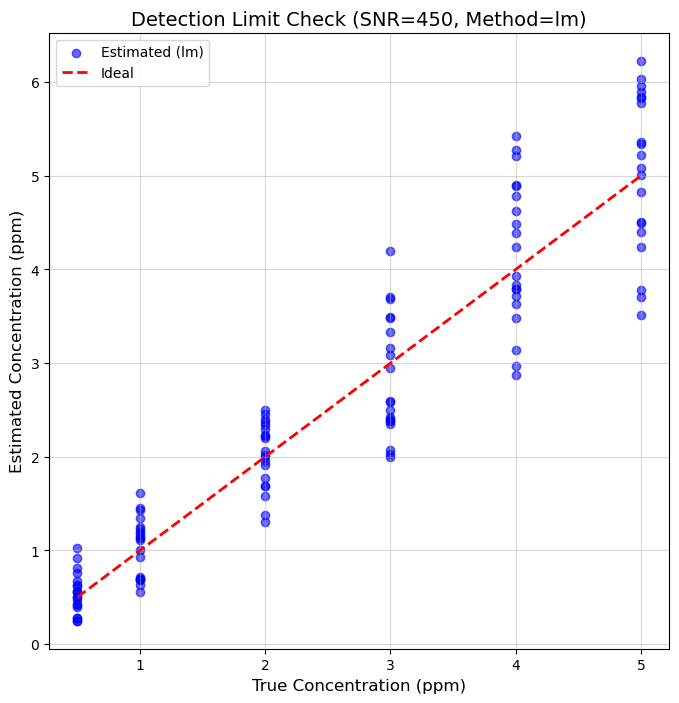

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from tqdm import tqdm

# =========================================================
# 1. 設定 & 定数
# =========================================================
LUT_FILE = r"E:\refit\water_lut\2.0.csv"
HISUI_FILE = r"E:\新しいフォルダー\pixel_1000_1000.csv"
SNR = 450
TRIALS = 20

# 検出限界を調べるための濃度ステップ
TRUE_CONCENTRATIONS = [0.5, 1.0, 2.0, 3.0, 4.0, 5.0] 

hi_i = 110
hi_f = 121
mo_i = 1800
mo_f = 2121

# =========================================================
# 2. 関数群 (抽出・適合・推定)
# =========================================================

def extract_ch4(data):
    if data.ndim != 2 or mo_f > data.shape[1] or mo_i < 0:
        raise ValueError("Invalid shape or indices for extract_ch4")
    return data[:, mo_i:mo_f]

def instrumental_function(data, sigma, mu):
    wavelengths = data[0, :]
    num_levels = data.shape[0] - 1
    out = np.zeros_like(data)
    out[0, :] = wavelengths
    ave_wave = np.mean(wavelengths)
    sigma = max(sigma, 1e-6) # ゼロ除算防止
    
    gauss = np.exp(-(wavelengths - ave_wave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
    for i in range(1, num_levels + 1):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode='same')
    return out

def reflectance_correction(data, a, b, k):
    data_corrected = data.copy()
    wavelengths = data_corrected[0, :]
    num_levels = data_corrected.shape[0] - 1
    for i in range(1, num_levels + 1):
        reflectance_factor = a + b * wavelengths
        # lm法では負の値も探索しうるため、物理的制約としてのclipのみ残すか検討
        # ここでは計算エラー防止のため正値化
        reflectance_factor = np.maximum(reflectance_factor, 1e-9)
        data_corrected[i, :] = data_corrected[i, :] * reflectance_factor + k
    return data_corrected

def estimated_by_ch4(data, c):
    # 濃度cが範囲外になっても外挿せず、端の値を使う（または線形外挿）
    # ここでは元のロジック通り端の値でクリップ
    num_levels = data.shape[0] - 1
    ch4_levels = np.arange(0, 0.25 * num_levels, 0.25) 

    if c <= ch4_levels[0]: position = 1
    elif c >= ch4_levels[-1]: position = len(ch4_levels) - 1
    else: position = np.searchsorted(ch4_levels, c)

    idx_lower, idx_upper = position, position + 1
    if idx_upper >= data.shape[0]:
        idx_upper = idx_lower = data.shape[0] - 1
    elif idx_lower < 1:
        idx_lower = 1
        idx_upper = idx_lower

    level_lower = ch4_levels[position-1]
    level_upper = ch4_levels[position]
    
    level_step = level_upper - level_lower
    r = (c - level_lower) / level_step if level_step > 0 else 0.0
    
    interpolated_values = (1 - r) * data[idx_lower, :] + r * data[idx_upper, :]
    return interpolated_values.tolist()

def wavelength_adjustment_ch4(data_ch4_interpolated, modtran_wavelengths, data_hisui):
    if len(modtran_wavelengths) < 2: return []
    data_ch4_arr = np.asarray(data_ch4_interpolated)
    
    out = []
    for i in range(hi_i, hi_f):
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        
        if position == 0: out.append(data_ch4_arr[0])
        elif position >= len(modtran_wavelengths): out.append(data_ch4_arr[-1])
        else:
            w_low = modtran_wavelengths[position - 1]
            w_high = modtran_wavelengths[position]
            r = (hisui_wave - w_low) / (w_high - w_low)
            val = (1 - r) * data_ch4_arr[position - 1] + r * data_ch4_arr[position]
            out.append(val)
    return out

def func_ch4(data, data_hisui, sigma, mu, a, b, c, k):
    out = instrumental_function(data, sigma, mu)
    out_extracted = extract_ch4(out)
    wavelengths_ch4_range = out_extracted[0, :]
    out_reflectance_corrected = reflectance_correction(out_extracted.copy(), a, b, k)
    out_estimated = estimated_by_ch4(out_reflectance_corrected, c)
    out_adjusted = wavelength_adjustment_ch4(out_estimated, wavelengths_ch4_range, data_hisui)
    return out_adjusted

def residuals_ch4(param, data, data_hisui, observed_spectrum):
    sigma, mu, a, b, c, k = param
    # lm法は制約なしでパラメータを動かすため、異常値でのエラー回避
    if sigma < 0.1: sigma = 0.1 # 幅が細くなりすぎるのを防ぐ
    
    try:
        w_est = func_ch4(data, data_hisui, sigma, mu, a, b, c, k)
        w_est_np = np.asarray(w_est)
        return observed_spectrum - w_est_np
    except Exception:
        return np.full_like(observed_spectrum, 1e6)

def estimate_param_ch4_init(data_adjusted, data_hisui):
    obs_rad = data_hisui.iloc[hi_i:hi_f, 1].values
    obs_wave = data_hisui.iloc[hi_i:hi_f, 0].values
    
    if len(data_adjusted) != len(obs_rad): return 0.0, 0.0
    
    max_ref = np.max(obs_rad)
    rel_max_index = np.argmax(obs_rad)
    max_wave = obs_wave[rel_max_index]
    modtran_val_at_max = data_adjusted[rel_max_index]
    
    if max_wave == 0 or modtran_val_at_max == 0: return 0.0, 0.0
    
    b = max_ref / max_wave / modtran_val_at_max
    a = 0.0
    return b, a

# =========================================================
# 3. メイン処理
# =========================================================

print("Loading Data...")
df_lut = pd.read_csv(LUT_FILE)
data_ch4_raw = df_lut.to_numpy()
data_ch4_np = data_ch4_raw.T.astype(float) 
data_ch4_np[1:, :] = data_ch4_np[1:, :] * 100 

df_pixel = pd.read_csv(HISUI_FILE)
data_hisui_template = df_pixel.iloc[:, [0, 1]].copy()
data_hisui_template.columns = ["Wavelength", "Radiance"]

# --- 初期パラメータの自動推定 (lm法の収束安定化のため) ---
# 1. HISUIデータの実測値を取得
real_obs_rad = data_hisui_template.iloc[hi_i:hi_f, 1].values
real_obs_wave = data_hisui_template.iloc[hi_i:hi_f, 0].values

# 2. オフセット(k)とスケール(b)の概算
auto_k = np.min(real_obs_rad)
lut_scale_assumption = 100.0 
mean_wave = np.mean(real_obs_wave)
auto_b = (np.max(real_obs_rad) - auto_k) / (lut_scale_assumption * mean_wave)
if auto_b <= 0: auto_b = 1e-5 

# 3. Sigmaの概算 (HISUIのFWHM≒10nmを想定)
auto_sigma = 5.62

print(f"\n[Auto-Estimated Init Params for lm]")
print(f"  Sigma : {auto_sigma:.4f}")
print(f"  b     : {auto_b:.4e}")
print(f"  k     : {auto_k:.4e}")

results_true = []
results_est = []

print("\nStarting Simulation Loop (Method: lm)...")

for true_conc in tqdm(TRUE_CONCENTRATIONS, desc="Testing Concentrations"):
    
    # シミュレーション用「正解」パラメータ
    # ここで「悪い設定」を使うとシミュレーション自体が破綻するため、
    # 妥当な推定値(auto_sigma等)を使って「理想的な観測データ」を作ります
    true_sigma = auto_sigma
    true_mu    = 0.0
    true_a     = 0.0
    true_b     = auto_b
    true_k     = auto_k

    true_spectrum_list = func_ch4(
        data_ch4_np, data_hisui_template, 
        true_sigma, true_mu, true_a, true_b, true_conc, true_k
    )
    true_spectrum = np.array(true_spectrum_list)
    
    for _ in range(TRIALS):
        # ノイズ付加
        noise_std = true_spectrum / SNR
        noise = np.random.normal(0, noise_std, size=len(true_spectrum))
        observed_spectrum = true_spectrum + noise
        
        # 観測データの更新
        data_hisui_current = data_hisui_template.copy()
        data_hisui_current.iloc[hi_i:hi_f, 1] = observed_spectrum
        
        # 探索用初期値の決定
        # lm法は初期値依存性が強いため、毎回データからある程度良い初期値を探す
        temp_spec = func_ch4(data_ch4_np, data_hisui_current, 6.5, 0.0, 0.0, auto_b, 1.8, auto_k)
        b_init, a_init = estimate_param_ch4_init(temp_spec, data_hisui_current)
        
        # x0 = [sigma, mu, a, b, c, k]
        # 初期濃度はあえて少しずらした1.8ppmなどにしておく
        x0 = [6.5, 0.0, a_init, b_init, 1.8, auto_k]
        
        try:
            # --- lm法で実行 (boundsなし) ---
            res = least_squares(
                residuals_ch4, x0, 
                args=(data_ch4_np, data_hisui_template, observed_spectrum),
                method='lm' 
            )
            
            estimated_conc = res.x[4]
            results_true.append(true_conc)
            results_est.append(estimated_conc)
            
        except Exception as e:
            pass

# =========================================================
# 4. 結果の可視化
# =========================================================
plt.figure(figsize=(8, 8))
plt.scatter(results_true, results_est, alpha=0.6, color='blue', label='Estimated (lm)')

min_val = min(TRUE_CONCENTRATIONS)
max_val = max(TRUE_CONCENTRATIONS)
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal')

plt.title(f"Detection Limit Check (SNR={SNR}, Method=lm)", fontsize=14)
plt.xlabel("True Concentration (ppm)", fontsize=12)
plt.ylabel("Estimated Concentration (ppm)", fontsize=12)
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()

In [ ]:
# ============================================
# 検出限界評価用 CH4 LUT シミュレーションコード
# （HISUI 本体コードとは独立）
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# ユーザー設定
# ============================
# >>> ここを自分の環境に合わせて変更してください <<<
LUT_CSV_PATH = r"E:\refit\water_lut\2.0.csv"  # 例: 今回添付された LUT

# 使用する波長範囲 [nm]（HISUI で実際に使っている 1600 nm 付近に合わせる）
WAVE_MIN = 1560.0
WAVE_MAX = 1660.0

# HISUI の SNR（全波長で一定と仮定）
SNR_HISUI = 450.0

# 1つの真値 CH4 濃度に対して何回ノイズを振るか（モンテカルロ回数）
N_REALIZATIONS = 200

# 真値として試す CH4 濃度（None の場合は LUT に含まれる全レベルを使用）
TRUE_CH4_LIST = None  # 例: [0.0, 0.5, 1.0, 2.0, 3.0, 5.0] などにしてもよい

# 乱数シード（再現性のため）
RANDOM_SEED = 0


# ============================
# LUT 読み込み
# ============================
def load_ch4_lut(csv_path, wave_min=None, wave_max=None):
    """
    csv_path: 2.0.csv のようなファイルパス
    wave_min, wave_max: 使用する波長範囲 (nm)

    戻り値:
        wavelengths: shape (N_wave,)
        ch4_levels: shape (N_level,)  ex) [0, 0.25, ..., 5]
        lut: shape (N_wave, N_level)  各列がある CH4 濃度のスペクトル
    """
    df = pd.read_csv(csv_path)

    # 1列目が波長 (例: 'waveln')
    wavelengths = df.iloc[:, 0].values.astype(float)

    # 2列目以降のカラム名を CH4 濃度 [ppm] とみなす
    ch4_cols = df.columns[1:]
    ch4_levels = np.array([float(c) for c in ch4_cols], dtype=float)

    # LUT 本体 shape: (N_wave, N_level)
    lut_full = df.iloc[:, 1:].values.astype(float)

    # 波長範囲で切り出し
    mask = np.ones_like(wavelengths, dtype=bool)
    if wave_min is not None:
        mask &= (wavelengths >= wave_min)
    if wave_max is not None:
        mask &= (wavelengths <= wave_max)

    wavelengths_sel = wavelengths[mask]
    lut_sel = lut_full[mask, :]

    return wavelengths_sel, ch4_levels, lut_sel


# ============================
# HISUI を模したノイズ付加
# ============================
def add_hisui_noise(spectrum, snr, rng=None):
    """
    spectrum: 1D array (N_wave,)
    snr: SNR_HISUI（例: 450）

    各波長で σ = |spectrum| / snr のガウスノイズを付加したスペクトルを返す。
    """
    spec = np.asarray(spectrum, dtype=float)
    sigma = np.abs(spec) / snr

    if rng is None:
        rng = np.random.default_rng()
    noise = rng.normal(loc=0.0, scale=sigma)
    return spec + noise


# ============================
# LUT による CH4 推定（最小二乗）
# ============================
def retrieve_ch4_lut_least_squares(obs_spectrum, lut_spectra, ch4_levels):
    """
    obs_spectrum: 1D array (N_wave,)
    lut_spectra: 2D array (N_wave, N_level)
    ch4_levels: 1D array (N_level,)

    各 CH4 レベルの LUT と観測スペクトルの二乗誤差を計算し，
    一番小さいものを推定値とする。
    """
    obs = np.asarray(obs_spectrum, dtype=float)
    lut = np.asarray(lut_spectra, dtype=float)

    # shape (N_wave, N_level)
    diff = lut - obs[:, None]
    se = np.sum(diff**2, axis=0)

    best_idx = int(np.argmin(se))
    return float(ch4_levels[best_idx]), float(se[best_idx]), best_idx


# ============================
# 検出限界のためのモンテカルロ実験本体
# ============================
def run_detection_limit_experiment(
    csv_path,
    snr=450.0,
    wave_min=1560.0,
    wave_max=1660.0,
    n_realizations=200,
    true_ch4_list=None,
    seed=0,
):
    """
    csv_path: CH4 LUT (2.0.csv 等)
    snr: HISUI の SNR
    wave_min, wave_max: 使用する波長範囲
    n_realizations: 1つの真値につき何回ノイズを振るか
    true_ch4_list: 真値として試す CH4 濃度のリスト
                   None の場合は LUT に含まれる全レベルを使用
    seed: 乱数シード

    戻り値:
        wavelengths, ch4_levels, lut, df_results
    """
    wavelengths, ch4_levels, lut = load_ch4_lut(csv_path, wave_min, wave_max)
    rng = np.random.default_rng(seed)

    if true_ch4_list is None:
        true_ch4_list = ch4_levels
    true_ch4_list = np.asarray(true_ch4_list, dtype=float)

    results = []
    for c_true in true_ch4_list:
        # LUT 内で最も近い CH4 レベルを真値として採用
        idx_true = int(np.argmin(np.abs(ch4_levels - c_true)))
        spec_true = lut[:, idx_true]

        for trial in range(n_realizations):
            obs = add_hisui_noise(spec_true, snr, rng)
            est_ch4, chi2, idx_est = retrieve_ch4_lut_least_squares(
                obs, lut, ch4_levels
            )
            results.append(
                dict(
                    true_ch4=float(c_true),
                    true_idx=idx_true,
                    est_ch4=est_ch4,
                    est_idx=idx_est,
                    chi2=chi2,
                    trial=trial,
                )
            )

    df_results = pd.DataFrame(results)
    return wavelengths, ch4_levels, lut, df_results


# ============================
# 結果の統計 & 検出下限の簡易評価
# ============================
def summarize_results(df_results):
    """
    true_ch4 ごとに est_ch4 の平均・標準偏差・バイアスを計算
    """
    g = df_results.groupby("true_ch4")["est_ch4"]
    summary = g.agg(["mean", "std", "count"])
    summary["bias"] = summary["mean"] - summary.index
    return summary


def estimate_detection_limit(summary, max_allowed_bias=0.25, max_allowed_std=0.5):
    """
    非常に「ざっくりした例」として：
      - バイアス |mean - true| <= max_allowed_bias
      - 標準偏差 std <= max_allowed_std
    を両方満たす最小の true_ch4 を検出下限と定義する。
    """
    ok = (summary["bias"].abs() <= max_allowed_bias) & (
        summary["std"] <= max_allowed_std
    )
    if not ok.any():
        return None
    return float(ok[ok].index.min())


def plot_true_vs_est(df_results, out_png=None):
    """
    真値 vs 推定値 の散布図を描き、y=x 線も描く。
    """
    xmin = df_results[["true_ch4", "est_ch4"]].min().min()
    xmax = df_results[["true_ch4", "est_ch4"]].max().max()
    margin = 0.1 * (xmax - xmin + 1e-9)
    lo = xmin - margin
    hi = xmax + margin

    plt.figure(figsize=(6, 6))
    plt.scatter(df_results["true_ch4"], df_results["est_ch4"], alpha=0.3, s=10)
    plt.plot([lo, hi], [lo, hi], linestyle="--")
    plt.xlabel("True CH₄ [ppm]")
    plt.ylabel("Retrieved CH₄ [ppm]")
    plt.grid(True, alpha=0.3)
    plt.gca().set_aspect("equal", "box")
    plt.tight_layout()

    if out_png is not None:
        plt.savefig(out_png, dpi=150)
        plt.close()
    else:
        plt.show()


# ============================
# スクリプトとして実行したとき
# ============================
if __name__ == "__main__":
    # --- 実験実行 ---
    wavelengths, ch4_levels, lut, df_results = run_detection_limit_experiment(
        csv_path=LUT_CSV_PATH,
        snr=SNR_HISUI,
        wave_min=WAVE_MIN,
        wave_max=WAVE_MAX,
        n_realizations=N_REALIZATIONS,
        true_ch4_list=TRUE_CH4_LIST,
        seed=RANDOM_SEED,
    )

    print("Wavelength range used: ", wavelengths.min(), "–", wavelengths.max(), "nm")
    print("CH₄ levels in LUT [ppm]:", ch4_levels)

    # --- 統計的まとめ ---
    summary = summarize_results(df_results)
    print("\n=== Summary (per true CH4) ===")
    print(summary)

    det_lim = estimate_detection_limit(summary)
    print("\nEstimated detection limit (example criterion):", det_lim, "ppm")

    # --- CSV で保存 ---
    df_results.to_csv("ch4_detection_mc_results.csv", index=False)
    summary.to_csv("ch4_detection_summary.csv")

    # --- 図を保存 ---
    plot_true_vs_est(df_results, out_png="ch4_true_vs_est.png")
    print("\nResults saved: ch4_detection_mc_results.csv, ch4_detection_summary.csv, ch4_true_vs_est.png")


--- Loading Data ---
LUT Loaded: (22, 2121)
True Sigma (from B-file): 5.5948 (FWHM=13.18nm)
Target Wavelengths: 16 bands (2212.47-2399.82nm)
Selected Pixel Index: 0
Pixel Radiance Range: 1.5328 - 4.3968

[Calculated True Parameters]
  k (Offset) : 1.5328
  b (Scale)  : 9.9243e-05
  Sigma      : 5.5948

--- Starting Simulation (SNR=450) ---


Simulating: 100%|██████████| 7/7 [00:04<00:00,  1.71it/s]


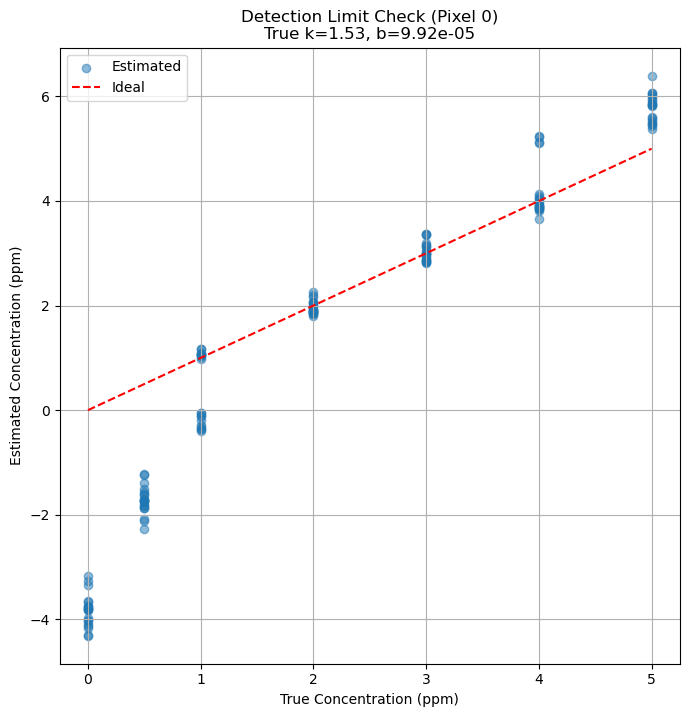

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import re
from tqdm import tqdm

# =========================================================
# 1. 設定パラメータ
# =========================================================
LUT_FILE = r"E:\refit\water_lut\2.0.csv"
SPECTRA_FILE = r"E:\refit\all_roi_spectra.csv"  # ピクセルデータ
INSTRUMENT_FILE = r"E:\メタン\2025_HISUI_72_The Permian Basin-論文照合用\HSHL1G_N320W1032_20221030160051_20231127193053\HSHL1G_N320W1032_20221030160051_20231127193053_B.csv"

SNR = 450
TRIALS = 20
TRUE_CONCENTRATIONS = [0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0]

# ターゲットとするピクセルのインデックス (0行目を選択)
TARGET_PIXEL_IDX = 0 

# 解析する波長範囲 (nm)
TARGET_WAVE_RANGE = (2200, 2400)

# =========================================================
# 2. ユーティリティ関数
# =========================================================
def parse_wavelengths(columns):
    """カラム名 (wave_xxx.xxnm) から波長リストとインデックスを取得"""
    waves = []
    cols_in_range = []
    
    for col in columns:
        match = re.search(r'wave_([\d\.]+)nm', col)
        if match:
            w = float(match.group(1))
            if TARGET_WAVE_RANGE[0] <= w <= TARGET_WAVE_RANGE[1]:
                waves.append(w)
                cols_in_range.append(col)
                
    return np.array(waves), cols_in_range

def instrumental_function(data, sigma, mu):
    wavelengths = data[0, :]
    out = np.zeros_like(data)
    out[0, :] = wavelengths
    sigma = max(sigma, 1e-6)
    
    dx = np.mean(np.diff(wavelengths))
    radius = int(4 * sigma / dx)
    kernel_x = np.arange(-radius, radius + 1) * dx
    kernel = np.exp(-(kernel_x - mu)**2 / (2 * sigma**2))
    kernel /= np.sum(kernel)
    
    for i in range(1, data.shape[0]):
        out[i, :] = np.convolve(data[i, :], kernel, mode='same')
    return out

def get_lut_value(data_lut, conc):
    """LUTから指定濃度のスペクトルを線形補間"""
    conc_step = 0.25
    max_conc = (data_lut.shape[0] - 2) * conc_step
    
    if conc <= 0: return data_lut[1, :]
    if conc >= max_conc: return data_lut[-1, :]
    
    idx_float = conc / conc_step
    idx_low = int(np.floor(idx_float))
    r = idx_float - idx_low
    
    val_low = data_lut[idx_low + 1, :]
    val_high = data_lut[idx_low + 2, :]
    return (1 - r) * val_low + r * val_high

def forward_model(lut_data, target_waves, sigma, mu, a, b, c, k):
    # 1. 装置関数畳み込み
    lut_conv = instrumental_function(lut_data, sigma, mu)
    lut_waves = lut_conv[0, :]
    
    # 2. 濃度cのスペクトル取得
    spec_lut = get_lut_value(lut_conv, c)
    
    # 3. 波長リサンプリング
    spec_resampled = np.interp(target_waves, lut_waves, spec_lut)
    
    # 4. 反射率・オフセット適用
    # Model: Radiance = (a + b*wave) * LUT_val + k
    refl = a + b * target_waves
    refl = np.maximum(refl, 1e-9)
    return spec_resampled * refl + k

def residuals(params, lut_data, target_waves, obs_spec):
    sigma, mu, a, b, c, k = params
    if sigma < 0.1: sigma = 0.1
    if c < 0: c = 0
    
    est_spec = forward_model(lut_data, target_waves, sigma, mu, a, b, c, k)
    return obs_spec - est_spec

# =========================================================
# 3. メイン処理
# =========================================================

print("--- Loading Data ---")

# 1. LUT読み込み
df_lut = pd.read_csv(LUT_FILE)
data_lut = df_lut.to_numpy().T.astype(float)
data_lut[1:, :] *= 100 # スケーリング
print(f"LUT Loaded: {data_lut.shape}")

# 2. Instrument (B file) から Sigma を取得
try:
    df_inst = pd.read_csv(INSTRUMENT_FILE)
    df_swir = df_inst[(df_inst['CenterWavelengthNanometer'] >= TARGET_WAVE_RANGE[0]) & 
                      (df_inst['CenterWavelengthNanometer'] <= TARGET_WAVE_RANGE[1])]
    mean_fwhm = df_swir['FullWidthAtHalfMaximumNanometer'].mean()
    true_sigma = mean_fwhm / 2.355
    print(f"True Sigma (from B-file): {true_sigma:.4f} (FWHM={mean_fwhm:.2f}nm)")
except:
    true_sigma = 5.6 # フォールバック
    print("Warning: Could not load B-file, using default Sigma=5.6")

# 3. Pixel Data (Spectra) から k, b を決定
df_spectra = pd.read_csv(SPECTRA_FILE)
target_waves, target_cols = parse_wavelengths(df_spectra.columns)
print(f"Target Wavelengths: {len(target_waves)} bands ({target_waves[0]:.2f}-{target_waves[-1]:.2f}nm)")

# 指定ピクセルのデータを取得
pixel_data = df_spectra.iloc[TARGET_PIXEL_IDX][target_cols].values.astype(float)
print(f"Selected Pixel Index: {TARGET_PIXEL_IDX}")
print(f"Pixel Radiance Range: {pixel_data.min():.4f} - {pixel_data.max():.4f}")

# Trueパラメータの計算
# true_k = 最小輝度
true_k = np.min(pixel_data)

# true_b = (最大輝度 - k) / (平均波長 * LUT最大値)
mean_wave = np.mean(target_waves)
# LUTの対応する範囲の最大値を取得 (0ppm列を使用)
lut_waves = data_lut[0, :]
lut_indices = np.where((lut_waves >= TARGET_WAVE_RANGE[0]) & (lut_waves <= TARGET_WAVE_RANGE[1]))[0]
lut_max_val = np.max(data_lut[1, lut_indices]) # 1行目=0ppm

true_b = (np.max(pixel_data) - true_k) / (mean_wave * lut_max_val)

print(f"\n[Calculated True Parameters]")
print(f"  k (Offset) : {true_k:.4f}")
print(f"  b (Scale)  : {true_b:.4e}")
print(f"  Sigma      : {true_sigma:.4f}")

# 高速化のためLUTを必要範囲で切り出し (マージンを持たせる)
lut_start = max(0, lut_indices[0] - 50)
lut_end = min(data_lut.shape[1], lut_indices[-1] + 50)
lut_crop = data_lut[:, lut_start:lut_end]

# =========================================================
# 4. シミュレーション実行
# =========================================================
print(f"\n--- Starting Simulation (SNR={SNR}) ---")
results_true = []
results_est = []

for true_c in tqdm(TRUE_CONCENTRATIONS, desc="Simulating"):
    # 1. 正解スペクトル生成 (Forward)
    true_spec = forward_model(
        lut_crop, target_waves, 
        true_sigma, 0.0, 0.0, true_b, true_c, true_k
    )
    
    for _ in range(TRIALS):
        # 2. ノイズ付加
        noise_std = true_spec / SNR
        noise = np.random.normal(0, noise_std, size=len(true_spec))
        obs_spec = true_spec + noise
        
        # 3. 推定 (Inverse)
        # 初期値推定: データから逆算
        init_k = np.min(obs_spec)
        init_b = (np.max(obs_spec) - init_k) / (mean_wave * lut_max_val)
        
        # x0 = [sigma, mu, a, b, c, k]
        x0 = [6.5, 0.0, 0.0, init_b, 1.8, init_k]
        
        try:
            res = least_squares(
                residuals, x0, 
                args=(lut_crop, target_waves, obs_spec),
                method='lm'
            )
            results_true.append(true_c)
            results_est.append(res.x[4])
        except:
            pass

# =========================================================
# 5. 結果可視化
# =========================================================
plt.figure(figsize=(8, 8))
plt.scatter(results_true, results_est, alpha=0.5, label='Estimated')
min_c, max_c = min(TRUE_CONCENTRATIONS), max(TRUE_CONCENTRATIONS)
plt.plot([min_c, max_c], [min_c, max_c], 'r--', label='Ideal')
plt.title(f"Detection Limit Check (Pixel {TARGET_PIXEL_IDX})\nTrue k={true_k:.2f}, b={true_b:.2e}")
plt.xlabel("True Concentration (ppm)")
plt.ylabel("Estimated Concentration (ppm)")
plt.grid(True)
plt.legend()
plt.show()

--- Loading Data ---
LUT Loaded: (28, 2121)
True Sigma (from B-file): 5.6190 (FWHM=13.23nm)
Target Wavelengths: 10 bands (1625.43-1737.85nm)
Selected Pixel Index: 0
Pixel Radiance Range: 11.1616 - 16.3840

[Calculated True Parameters]
  k (Offset) : 11.1616
  b (Scale)  : 8.4387e-05
  Sigma      : 5.6190

--- Starting Simulation (SNR=450) ---


Simulating:   0%|          | 0/9 [00:00<?, ?it/s]C:\Users\sal\AppData\Local\Temp\ipykernel_1128\1572710678.py:53: RuntimeWarning: invalid value encountered in divide
  kernel /= np.sum(kernel)
Simulating: 100%|██████████| 9/9 [00:10<00:00,  1.19s/it]


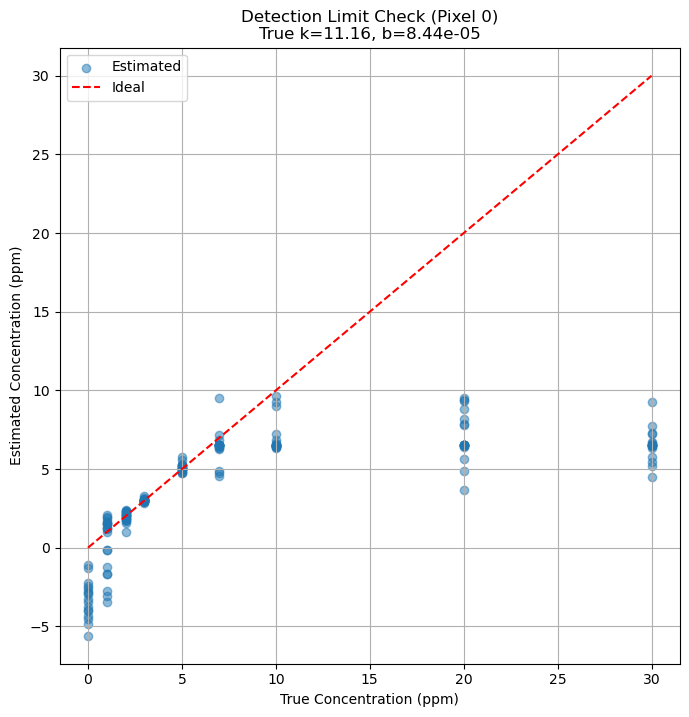

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import re
from tqdm import tqdm

# =========================================================
# 1. 設定パラメータ
# =========================================================
LUT_FILE = r"E:\tools\thesis\16genkai\lut.csv"
SPECTRA_FILE = r"E:\refit\all_roi_spectra.csv"  # ピクセルデータ
INSTRUMENT_FILE = r"E:\メタン\2025_HISUI_72_The Permian Basin-論文照合用\HSHL1G_N320W1032_20221030160051_20231127193053\HSHL1G_N320W1032_20221030160051_20231127193053_B.csv"

SNR = 450
TRIALS = 20
TRUE_CONCENTRATIONS = [0.00,1.00,2.00,3.00,5.00,7.00,10.00,20.00,30.00]

# ターゲットとするピクセルのインデックス (0行目を選択)
TARGET_PIXEL_IDX = 0 

# 解析する波長範囲 (nm)
TARGET_WAVE_RANGE = (1625, 1750)

# =========================================================
# 2. ユーティリティ関数
# =========================================================
def parse_wavelengths(columns):
    """カラム名 (wave_xxx.xxnm) から波長リストとインデックスを取得"""
    waves = []
    cols_in_range = []
    
    for col in columns:
        match = re.search(r'wave_([\d\.]+)nm', col)
        if match:
            w = float(match.group(1))
            if TARGET_WAVE_RANGE[0] <= w <= TARGET_WAVE_RANGE[1]:
                waves.append(w)
                cols_in_range.append(col)
                
    return np.array(waves), cols_in_range

def instrumental_function(data, sigma, mu):
    wavelengths = data[0, :]
    out = np.zeros_like(data)
    out[0, :] = wavelengths
    sigma = max(sigma, 1e-6)
    
    dx = np.mean(np.diff(wavelengths))
    radius = int(4 * sigma / dx)
    kernel_x = np.arange(-radius, radius + 1) * dx
    kernel = np.exp(-(kernel_x - mu)**2 / (2 * sigma**2))
    kernel /= np.sum(kernel)
    
    for i in range(1, data.shape[0]):
        out[i, :] = np.convolve(data[i, :], kernel, mode='same')
    return out

def get_lut_value(data_lut, conc):
    """LUTから指定濃度のスペクトルを線形補間"""
    conc_step = 0.25
    max_conc = (data_lut.shape[0] - 2) * conc_step
    
    if conc <= 0: return data_lut[1, :]
    if conc >= max_conc: return data_lut[-1, :]
    
    idx_float = conc / conc_step
    idx_low = int(np.floor(idx_float))
    r = idx_float - idx_low
    
    val_low = data_lut[idx_low + 1, :]
    val_high = data_lut[idx_low + 2, :]
    return (1 - r) * val_low + r * val_high

def forward_model(lut_data, target_waves, sigma, mu, a, b, c, k):
    # 1. 装置関数畳み込み
    lut_conv = instrumental_function(lut_data, sigma, mu)
    lut_waves = lut_conv[0, :]
    
    # 2. 濃度cのスペクトル取得
    spec_lut = get_lut_value(lut_conv, c)
    
    # 3. 波長リサンプリング
    spec_resampled = np.interp(target_waves, lut_waves, spec_lut)
    
    # 4. 反射率・オフセット適用
    # Model: Radiance = (a + b*wave) * LUT_val + k
    refl = a + b * target_waves
    refl = np.maximum(refl, 1e-9)
    return spec_resampled * refl + k

def residuals(params, lut_data, target_waves, obs_spec):
    sigma, mu, a, b, c, k = params
    if sigma < 0.1: sigma = 0.1
    if c < 0: c = 0
    
    est_spec = forward_model(lut_data, target_waves, sigma, mu, a, b, c, k)
    return obs_spec - est_spec

# =========================================================
# 3. メイン処理
# =========================================================

print("--- Loading Data ---")

# 1. LUT読み込み
df_lut = pd.read_csv(LUT_FILE)
data_lut = df_lut.to_numpy().T.astype(float)
data_lut[1:, :] *= 100 # スケーリング
print(f"LUT Loaded: {data_lut.shape}")

# 2. Instrument (B file) から Sigma を取得
try:
    df_inst = pd.read_csv(INSTRUMENT_FILE)
    df_swir = df_inst[(df_inst['CenterWavelengthNanometer'] >= TARGET_WAVE_RANGE[0]) & 
                      (df_inst['CenterWavelengthNanometer'] <= TARGET_WAVE_RANGE[1])]
    mean_fwhm = df_swir['FullWidthAtHalfMaximumNanometer'].mean()
    true_sigma = mean_fwhm / 2.355
    print(f"True Sigma (from B-file): {true_sigma:.4f} (FWHM={mean_fwhm:.2f}nm)")
except:
    true_sigma = 5.6 # フォールバック
    print("Warning: Could not load B-file, using default Sigma=5.6")

# 3. Pixel Data (Spectra) から k, b を決定
df_spectra = pd.read_csv(SPECTRA_FILE)
target_waves, target_cols = parse_wavelengths(df_spectra.columns)
print(f"Target Wavelengths: {len(target_waves)} bands ({target_waves[0]:.2f}-{target_waves[-1]:.2f}nm)")

# 指定ピクセルのデータを取得
pixel_data = df_spectra.iloc[TARGET_PIXEL_IDX][target_cols].values.astype(float)
print(f"Selected Pixel Index: {TARGET_PIXEL_IDX}")
print(f"Pixel Radiance Range: {pixel_data.min():.4f} - {pixel_data.max():.4f}")

# Trueパラメータの計算
# true_k = 最小輝度
true_k = np.min(pixel_data)

# true_b = (最大輝度 - k) / (平均波長 * LUT最大値)
mean_wave = np.mean(target_waves)
# LUTの対応する範囲の最大値を取得 (0ppm列を使用)
lut_waves = data_lut[0, :]
lut_indices = np.where((lut_waves >= TARGET_WAVE_RANGE[0]) & (lut_waves <= TARGET_WAVE_RANGE[1]))[0]
lut_max_val = np.max(data_lut[1, lut_indices]) # 1行目=0ppm

true_b = (np.max(pixel_data) - true_k) / (mean_wave * lut_max_val)

print(f"\n[Calculated True Parameters]")
print(f"  k (Offset) : {true_k:.4f}")
print(f"  b (Scale)  : {true_b:.4e}")
print(f"  Sigma      : {true_sigma:.4f}")

# 高速化のためLUTを必要範囲で切り出し (マージンを持たせる)
lut_start = max(0, lut_indices[0] - 50)
lut_end = min(data_lut.shape[1], lut_indices[-1] + 50)
lut_crop = data_lut[:, lut_start:lut_end]

# =========================================================
# 4. シミュレーション実行
# =========================================================
print(f"\n--- Starting Simulation (SNR={SNR}) ---")
results_true = []
results_est = []

for true_c in tqdm(TRUE_CONCENTRATIONS, desc="Simulating"):
    # 1. 正解スペクトル生成 (Forward)
    true_spec = forward_model(
        lut_crop, target_waves, 
        true_sigma, 0.0, 0.0, true_b, true_c, true_k
    )
    
    for _ in range(TRIALS):
        # 2. ノイズ付加
        noise_std = true_spec / SNR
        noise = np.random.normal(0, noise_std, size=len(true_spec))
        obs_spec = true_spec + noise
        
        # 3. 推定 (Inverse)
        # 初期値推定: データから逆算
        init_k = np.min(obs_spec)
        init_b = (np.max(obs_spec) - init_k) / (mean_wave * lut_max_val)
        
        # x0 = [sigma, mu, a, b, c, k]
        x0 = [6.5, 0.0, 0.0, init_b, 1.8, init_k]
        
        try:
            res = least_squares(
                residuals, x0, 
                args=(lut_crop, target_waves, obs_spec),
                method='lm'
            )
            results_true.append(true_c)
            results_est.append(res.x[4])
        except:
            pass

# =========================================================
# 5. 結果可視化
# =========================================================
plt.figure(figsize=(8, 8))
plt.scatter(results_true, results_est, alpha=0.5, label='Estimated')
min_c, max_c = min(TRUE_CONCENTRATIONS), max(TRUE_CONCENTRATIONS)
plt.plot([min_c, max_c], [min_c, max_c], 'r--', label='Ideal')
plt.title(f"Detection Limit Check (Pixel {TARGET_PIXEL_IDX})\nTrue k={true_k:.2f}, b={true_b:.2e}")
plt.xlabel("True Concentration (ppm)")
plt.ylabel("Estimated Concentration (ppm)")
plt.grid(True)
plt.legend()
plt.show()

--- Loading Data ---
Full LUT Loaded: (67, 2121), Levels: [   0.      1.      1.5     1.75    1.8     1.9     2.      2.25    2.5
    3.      3.25    3.5     4.      4.25    4.5     4.75    5.      5.25
    5.5     6.      6.5     7.      7.5     8.      8.5     9.      9.5
   10.     10.5    11.     11.5    12.     12.5    13.     13.5    14.
   14.5    15.     15.5    16.     17.     18.     19.     20.     21.
   22.     23.     24.     25.     30.     35.     40.     45.     50.
   55.     70.     75.    100.    150.    200.    250.    300.    400.
  500.    700.   1000.  ]
Creating Retrieval Dictionary from levels: [1.5, 1.75, 2.0, 2.5, 3.5, 4.0, 4.5, 4.75, 5.0, 5.25, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0, 55.0, 70.0, 75.0, 100.0, 150.0, 200.0, 250.0, 300.0, 400.0, 500.0, 700.0, 1000.0]
Retrieval LUT shape: (59, 212

Simulating: 100%|██████████| 8/8 [00:19<00:00,  2.46s/it]


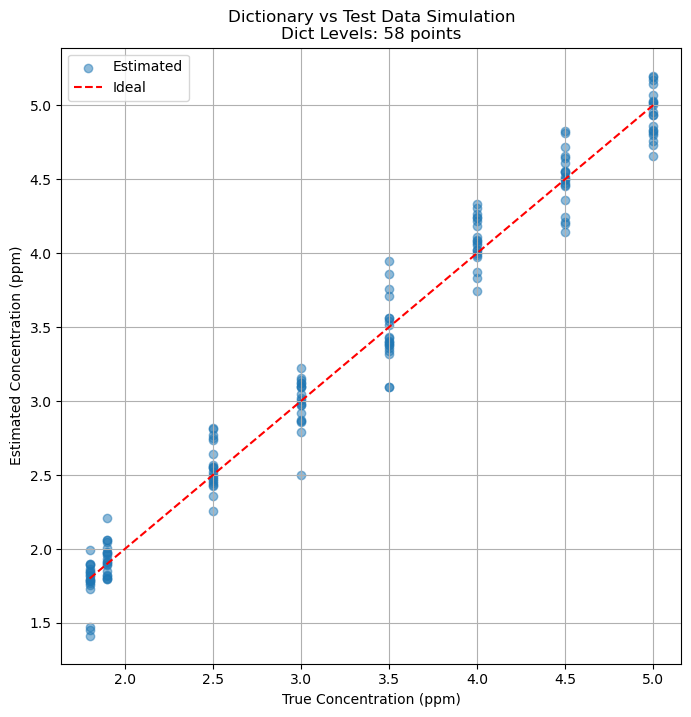

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import re
from tqdm import tqdm

# =========================================================
# 1. 設定パラメータ
# =========================================================
LUT_FILE = r"E:\tools\thesis\16genkai\lut.csv"
SPECTRA_FILE = r"E:\refit\all_roi_spectra.csv"  # ピクセルデータ
INSTRUMENT_FILE = r"E:\メタン\2025_HISUI_72_The Permian Basin-論文照合用\HSHL1G_N320W1032_20221030160051_20231127193053\HSHL1G_N320W1032_20221030160051_20231127193053_B.csv"

SNR = 450
TRIALS = 20

# ---------------------------------------------------------
# ★ここを個別に指定してください
# ---------------------------------------------------------

# ① 正解データ（辞書/参照用）として使う濃度リスト
#    推定時にアルゴリズムが「知っている」データ点です。
RETRIEVAL_USE_LEVELS = [1.50,1.75,2.00,2.50,3.50,4.00,4.50,4.75,5.00,5.25,5.50,6.00,6.50,7.00,7.50,8.00,8.50,9.00,9.50,10.00,10.50,11.00,11.50,12.00,12.50,13.00,13.50,14.00,14.50,15.00,15.50,16.00,17.00,18.00,19.00,20.00,21.00,22.00,23.00,24.00,25.00,30.00,35.00,40.00,45.00,50.00,55.00,70.00,75.00,100.00,150.00,200.00,250.00,300.00,400.00,500.00,700.00,1000.00] 
# 例: 間引く場合 -> [0, 2, 4] など

# ② 問題データ（テスト用）として使う濃度リスト
#    実際にシミュレーションで「正解」として生成される濃度です。
#    LUTファイルに含まれている必要があります。
TEST_PROBLEM_LEVELS = [1.80, 1.90, 2.10,2.20,2.30,2.40,2.50,2.60,2.70,2.80,2.90,3.00,3.10,3.20,3.30,3.40,3.50,3.60,3.70,3.80,3.90,4.00,4.10,4.20,4.30,4.40,4.50,4.60,4.70,4.80,4.90,5.00]
# 例: 辞書の隙間をテスト -> [1, 3, 5] など

# ---------------------------------------------------------

TARGET_PIXEL_IDX = 0 
TARGET_WAVE_RANGE = (2200, 2400)

# =========================================================
# 2. 汎用・計算関数
# =========================================================

def load_lut_and_levels(filepath):
    """LUTファイルを読み込み、データと濃度レベルを返す"""
    df = pd.read_csv(filepath)
    try:
        levels = df.columns[1:].astype(float).to_numpy()
    except ValueError:
        raise ValueError("LUT header must be numeric concentration values.")
        
    data = df.to_numpy().T.astype(float)
    data[1:, :] = data[1:, :] * 100 # スケーリング
    return data, levels

def extract_lut_subset(data, all_levels, wanted_levels):
    """
    全LUTデータから、wanted_levelsに含まれる濃度だけのサブセットを作成する
    """
    # 波長列（0行目）は必ず含める
    subset_indices = [0] 
    valid_levels = []
    
    for level in wanted_levels:
        # 誤差を許容して一致する列を探す
        matches = np.where(np.isclose(all_levels, level))[0]
        if len(matches) > 0:
            # dataの列インデックスは levelsのインデックス + 1
            subset_indices.append(matches[0] + 1)
            valid_levels.append(level)
        else:
            print(f"Warning: Level {level} not found in LUT file. Skipped for retrieval dictionary.")
            
    if len(subset_indices) <= 1:
        raise ValueError("No valid levels found for retrieval dictionary!")

    # インデックスで抽出
    subset_data = data[subset_indices, :]
    return subset_data, np.array(valid_levels)

def parse_wavelengths(columns):
    waves = []
    cols_in_range = []
    for col in columns:
        match = re.search(r'wave_([\d\.]+)nm', col)
        if match:
            w = float(match.group(1))
            if TARGET_WAVE_RANGE[0] <= w <= TARGET_WAVE_RANGE[1]:
                waves.append(w)
                cols_in_range.append(col)
    return np.array(waves), cols_in_range

def instrumental_function(data, sigma, mu):
    wavelengths = data[0, :]
    out = np.zeros_like(data)
    out[0, :] = wavelengths
    sigma = max(sigma, 1e-6)
    
    dx = np.mean(np.diff(wavelengths))
    radius = int(4 * sigma / dx)
    kernel_x = np.arange(-radius, radius + 1) * dx
    kernel = np.exp(-(kernel_x - mu)**2 / (2 * sigma**2))
    kernel /= np.sum(kernel)
    
    for i in range(1, data.shape[0]):
        out[i, :] = np.convolve(data[i, :], kernel, mode='same')
    return out

def estimated_by_ch4(data, c, levels):
    """濃度cのスペクトルを補間取得"""
    if c <= levels[0]: return data[1, :].tolist()
    if c >= levels[-1]: return data[-1, :].tolist()
    
    # 完全一致チェック
    idx_exact = np.where(np.isclose(levels, c))[0]
    if len(idx_exact) > 0:
        return data[idx_exact[0] + 1, :].tolist()

    idx = np.searchsorted(levels, c)
    c_lower, c_upper = levels[idx - 1], levels[idx]
    row_lower, row_upper = idx, idx + 1 # dataは0行目が波長なので+1オフセット不要(levelsのidxは0始まりだがdataは1始まり...修正: idx=1ならdata[2]...)
    # いや、searchsortedが返すidxは「挿入位置」。
    # levels = [0, 2], c=1 -> idx=1. 
    # levels[0]=0, levels[1]=2. 
    # dataの対応行は: row0=Wave, row1=0ppm, row2=2ppm.
    # levels[0] -> data[1], levels[1] -> data[2].
    # 正しいマッピング:
    r = (c - c_lower) / (c_upper - c_lower)
    
    # dataの行番号は levelsのインデックス + 1
    return ((1 - r) * data[idx, :] + r * data[idx + 1, :]).tolist()

def forward_model(lut_data, lut_levels, target_waves, sigma, mu, a, b, c, k):
    lut_conv = instrumental_function(lut_data, sigma, mu)
    lut_waves = lut_conv[0, :]
    spec_lut = estimated_by_ch4(lut_conv, c, lut_levels)
    spec_resampled = np.interp(target_waves, lut_waves, spec_lut)
    refl = a + b * target_waves
    refl = np.maximum(refl, 1e-9)
    return spec_resampled * refl + k

def residuals(params, lut_data, lut_levels, target_waves, obs_spec):
    sigma, mu, a, b, c, k = params
    if sigma < 0.1: sigma = 0.1
    if c < 0: c = 0
    est_spec = forward_model(lut_data, lut_levels, target_waves, sigma, mu, a, b, c, k)
    return obs_spec - est_spec

# =========================================================
# 3. メイン処理
# =========================================================
print("--- Loading Data ---")

# 1. LUT読み込み (Full Data)
try:
    data_lut_full, levels_full = load_lut_and_levels(LUT_FILE)
    print(f"Full LUT Loaded: {data_lut_full.shape}, Levels: {levels_full}")
except Exception as e:
    print(f"Error loading LUT: {e}")
    exit()

# 2. リトリーバル用(辞書)データの作成
try:
    print(f"Creating Retrieval Dictionary from levels: {RETRIEVAL_USE_LEVELS}")
    data_lut_retrieval, levels_retrieval = extract_lut_subset(data_lut_full, levels_full, RETRIEVAL_USE_LEVELS)
    print(f"Retrieval LUT shape: {data_lut_retrieval.shape}, Levels: {levels_retrieval}")
except Exception as e:
    print(f"Error creating subset: {e}")
    exit()

# 3. テスト用(問題)レベルの確認
valid_test_levels = []
for c in TEST_PROBLEM_LEVELS:
    if np.any(np.isclose(levels_full, c)):
        valid_test_levels.append(c)
    else:
        print(f"Warning: Test level {c} not in LUT file. Skipping.")
print(f"Test Problems Levels: {valid_test_levels}")

# 4. Sigma & Params Estimation
try:
    df_inst = pd.read_csv(INSTRUMENT_FILE)
    df_swir = df_inst[(df_inst['CenterWavelengthNanometer'] >= TARGET_WAVE_RANGE[0]) & 
                      (df_inst['CenterWavelengthNanometer'] <= TARGET_WAVE_RANGE[1])]
    mean_fwhm = df_swir['FullWidthAtHalfMaximumNanometer'].mean()
    true_sigma = mean_fwhm / 2.355
except:
    true_sigma = 5.6

df_spectra = pd.read_csv(SPECTRA_FILE)
target_waves, target_cols = parse_wavelengths(df_spectra.columns)
pixel_data = df_spectra.iloc[TARGET_PIXEL_IDX][target_cols].values.astype(float)

true_k = np.min(pixel_data)
mean_wave = np.mean(target_waves)

# スケール推定にはRetrieval用のLUTを使用する
lut_waves = data_lut_retrieval[0, :]
spec_0ppm = estimated_by_ch4(data_lut_retrieval, 0.0, levels_retrieval)
spec_0ppm_res = np.interp(target_waves, lut_waves, spec_0ppm)
max_lut_val = np.max(spec_0ppm_res)

true_b = (np.max(pixel_data) - true_k) / (mean_wave * max_lut_val)
print(f"True Params -> k: {true_k:.4f}, b: {true_b:.4e}, Sigma: {true_sigma:.4f}")

# =========================================================
# 4. シミュレーション実行
# =========================================================
print(f"\n--- Starting Simulation (SNR={SNR}) ---")
results_true = []
results_est = []

# 高速化用クロップ (Retrieval用とFull用両方)
lut_mask_ret = (data_lut_retrieval[0, :] >= TARGET_WAVE_RANGE[0]-50) & (data_lut_retrieval[0, :] <= TARGET_WAVE_RANGE[1]+50)
lut_crop_retrieval = data_lut_retrieval[:, lut_mask_ret]

lut_mask_full = (data_lut_full[0, :] >= TARGET_WAVE_RANGE[0]-50) & (data_lut_full[0, :] <= TARGET_WAVE_RANGE[1]+50)
lut_crop_full = data_lut_full[:, lut_mask_full]

for true_c in tqdm(valid_test_levels, desc="Simulating"):
    # ① 問題データの作成
    # ここでは「Full LUT」を使って、正確なスペクトルを作る
    true_spec = forward_model(
        lut_crop_full, levels_full, target_waves, 
        true_sigma, 0.0, 0.0, true_b, true_c, true_k
    )
    
    for _ in range(TRIALS):
        # ノイズ付加
        noise_std = true_spec / SNR
        noise = np.random.normal(0, noise_std, size=len(true_spec))
        obs_spec = true_spec + noise
        
        # ② 推定 (Retrieval)
        # ここでは「Retrieval LUT (間引かれた辞書)」を使って推定させる
        init_k = np.min(obs_spec)
        init_b = (np.max(obs_spec) - init_k) / (mean_wave * max_lut_val)
        x0 = [6.5, 0.0, 0.0, init_b, 1.8, init_k]
        
        try:
            res = least_squares(
                residuals, x0, 
                args=(lut_crop_retrieval, levels_retrieval, target_waves, obs_spec),
                method='lm'
            )
            results_true.append(true_c)
            results_est.append(res.x[4])
        except:
            pass

# =========================================================
# 5. 結果可視化
# =========================================================
plt.figure(figsize=(8, 8))
plt.scatter(results_true, results_est, alpha=0.5, label='Estimated')
min_c, max_c = min(valid_test_levels), max(valid_test_levels)
plt.plot([min_c, max_c], [min_c, max_c], 'r--', label='Ideal')

plt.title(f"Dictionary vs Test Data Simulation\nDict Levels: {len(levels_retrieval)} points")
plt.xlabel("True Concentration (ppm)")
plt.ylabel("Estimated Concentration (ppm)")
plt.grid(True)
plt.legend()

plt.show()

--- Loading Data ---
Full LUT Loaded: (91, 2121), Levels: [0.   1.   1.5  1.75 1.8 ]...[ 300.  400.  500.  700. 1000.]
Creating Retrieval Dictionary...
Retrieval LUT shape: (87, 2121), Num Levels: 86
Test Problems Levels (Valid): [1.8, 1.9, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0]
Instrument FWHM: 13.18 nm -> Sigma: 5.5948
True Params -> k: 1.5328, b: 1.0118e-04, Sigma: 5.5948

--- Starting Simulation (SNR=450, Range=(2200, 2400)nm) ---


Simulating: 100%|██████████| 32/32 [01:21<00:00,  2.54s/it]


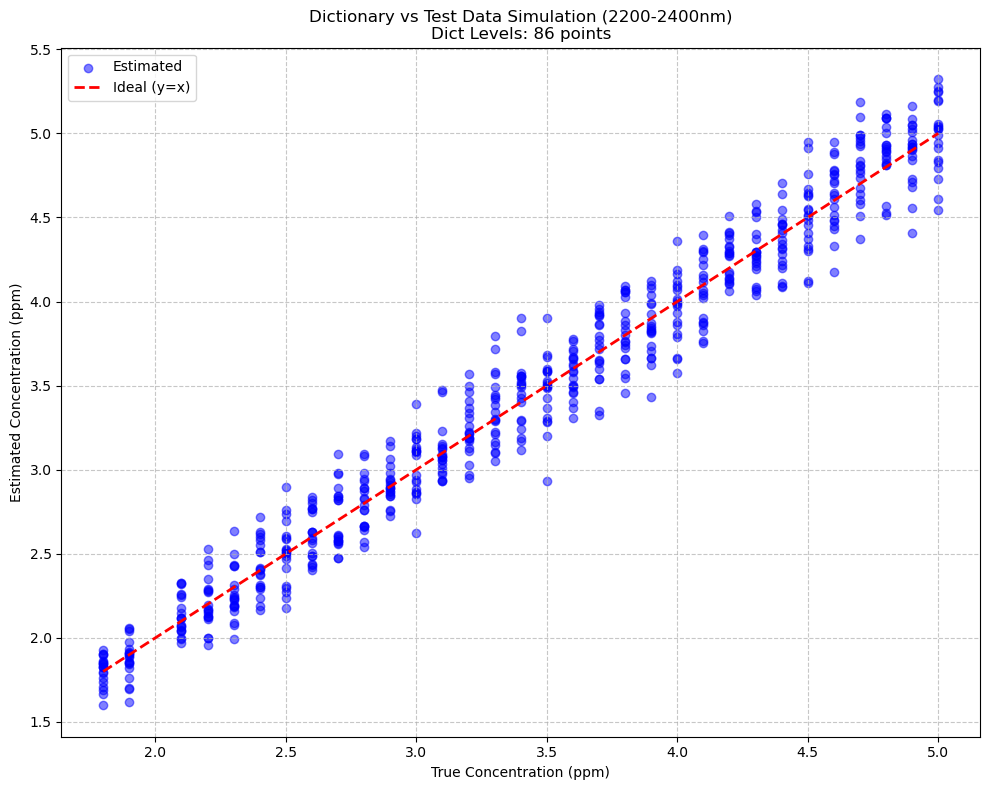

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import re
from tqdm import tqdm

# =========================================================
# 1. 設定パラメータ
# =========================================================
# ファイルパス (Windowsパス用に r"..." を使用)
LUT_FILE = r"E:\tools\thesis\16genkai\lutn.csv"
SPECTRA_FILE = r"E:\refit\all_roi_spectra.csv"
INSTRUMENT_FILE = r"E:\メタン\2025_HISUI_72_The Permian Basin-論文照合用\HSHL1G_N320W1032_20221030160051_20231127193053\HSHL1G_N320W1032_20221030160051_20231127193053_B.csv"

SNR = 450
TRIALS = 20

# ---------------------------------------------------------
# 濃度設定
# ---------------------------------------------------------

# ① 正解データ（辞書/参照用）として使う濃度リスト
#    推定時にアルゴリズムが「知っている」データ点
RETRIEVAL_USE_LEVELS = [0.00,1.00,1.50,2.00,2.10,2.20,2.25,2.30,2.40,2.50,2.60,2.70,2.80,2.90,3.10,3.20,3.25,3.30,3.40,3.50,3.60,3.70,3.80,3.90,4.00,4.10,4.20,4.25,4.30,4.40,4.50,4.60,4.70,4.75,4.80,4.90,5.00,5.25,5.50,6.00,6.50,7.00,7.50,8.00,8.50,9.00,9.50,10.00,10.50,11.00,11.50,12.00,12.50,13.00,13.50,14.00,14.50,15.00,15.50,16.00,17.00,18.00,19.00,20.00,21.00,22.00,23.00,24.00,25.00,30.00,35.00,40.00,45.00,50.00,55.00,70.00,75.00,100.00,150.00,200.00,250.00,300.00,400.00,500.00,700.00,1000.00]

# ② 問題データ（テスト用）として使う濃度リスト
#    シミュレーションで「正解」として生成される濃度 (LUTに含まれている必要あり)
TEST_PROBLEM_LEVELS = [1.80, 1.90, 2.10,2.20,2.30,2.40,2.50,2.60,2.70,2.80,2.90,3.00,3.10,3.20,3.30,3.40,3.50,3.60,3.70,3.80,3.90,4.00,4.10,4.20,4.30,4.40,4.50,4.60,4.70,4.80,4.90,5.00]

# ---------------------------------------------------------

TARGET_PIXEL_IDX = 0 
TARGET_WAVE_RANGE = (2200, 2400) # 2300nm帯

# =========================================================
# 2. 汎用・計算関数
# =========================================================

def load_lut_and_levels(filepath):
    """LUTファイルを読み込み、データと濃度レベルを返す"""
    df = pd.read_csv(filepath)
    try:
        # 1列目は波長、2列目以降が濃度
        levels = df.columns[1:].astype(float).to_numpy()
    except ValueError:
        raise ValueError("LUT header must be numeric concentration values.")
        
    data = df.to_numpy().T.astype(float)
    # ユーザー定義のスケーリング
    data[1:, :] = data[1:, :] * 100 
    return data, levels

def extract_lut_subset(data, all_levels, wanted_levels):
    """
    全LUTデータから、wanted_levelsに含まれる濃度だけのサブセットを作成する
    """
    subset_indices = [0] # 波長列
    valid_levels = []
    
    for level in wanted_levels:
        # 誤差を許容して一致する列を探す
        matches = np.where(np.isclose(all_levels, level))[0]
        if len(matches) > 0:
            # dataの列インデックスは levelsのインデックス + 1
            subset_indices.append(matches[0] + 1)
            valid_levels.append(level)
        else:
            # 辞書用レベルがLUTにない場合は警告のみでスキップ
            # print(f"Warning: Level {level} not found in LUT file. Skipped for retrieval dictionary.")
            pass
            
    if len(subset_indices) <= 1:
        raise ValueError("No valid levels found for retrieval dictionary!")

    subset_data = data[subset_indices, :]
    return subset_data, np.array(valid_levels)

def parse_wavelengths(columns):
    """カラム名から波長リストを取得"""
    waves = []
    cols_in_range = []
    for col in columns:
        match = re.search(r'wave_([\d\.]+)nm', col)
        if match:
            w = float(match.group(1))
            if TARGET_WAVE_RANGE[0] <= w <= TARGET_WAVE_RANGE[1]:
                waves.append(w)
                cols_in_range.append(col)
    return np.array(waves), cols_in_range

def instrumental_function(data, sigma, mu):
    wavelengths = data[0, :]
    out = np.zeros_like(data)
    out[0, :] = wavelengths
    sigma = max(sigma, 1e-6)
    
    dx = np.mean(np.diff(wavelengths))
    radius = int(4 * sigma / dx)
    kernel_x = np.arange(-radius, radius + 1) * dx
    kernel = np.exp(-(kernel_x - mu)**2 / (2 * sigma**2))
    kernel /= np.sum(kernel)
    
    for i in range(1, data.shape[0]):
        out[i, :] = np.convolve(data[i, :], kernel, mode='same')
    return out

def estimated_by_ch4(data, c, levels):
    """濃度cのスペクトルを補間取得"""
    if c <= levels[0]: return data[1, :].tolist()
    if c >= levels[-1]: return data[-1, :].tolist()
    
    # 完全一致チェック
    idx_exact = np.where(np.isclose(levels, c))[0]
    if len(idx_exact) > 0:
        return data[idx_exact[0] + 1, :].tolist()

    # 補間
    idx = np.searchsorted(levels, c)
    c_lower, c_upper = levels[idx - 1], levels[idx]
    # dataの行番号は levelsのインデックス + 1 (波長行があるため)
    # idxは挿入位置なので、idx-1番目の要素がlower、idx番目がupper
    # したがってデータ行は idx (lower) と idx+1 (upper)
    
    r = (c - c_lower) / (c_upper - c_lower)
    return ((1 - r) * data[idx, :] + r * data[idx + 1, :]).tolist()

def forward_model(lut_data, lut_levels, target_waves, sigma, mu, a, b, c, k):
    lut_conv = instrumental_function(lut_data, sigma, mu)
    lut_waves = lut_conv[0, :]
    spec_lut = estimated_by_ch4(lut_conv, c, lut_levels)
    spec_resampled = np.interp(target_waves, lut_waves, spec_lut)
    refl = a + b * target_waves
    refl = np.maximum(refl, 1e-9)
    return spec_resampled * refl + k

def residuals(params, lut_data, lut_levels, target_waves, obs_spec):
    sigma, mu, a, b, c, k = params
    if sigma < 0.1: sigma = 0.1
    if c < 0: c = 0
    est_spec = forward_model(lut_data, lut_levels, target_waves, sigma, mu, a, b, c, k)
    return obs_spec - est_spec


# =========================================================
# 3. メイン処理
# =========================================================
print("--- Loading Data ---")

# 1. LUT読み込み (Full Data)
try:
    data_lut_full, levels_full = load_lut_and_levels(LUT_FILE)
    print(f"Full LUT Loaded: {data_lut_full.shape}, Levels: {levels_full[:5]}...{levels_full[-5:]}")
except Exception as e:
    print(f"Error loading LUT: {e}")
    exit()

# 2. リトリーバル用(辞書)データの作成
try:
    print(f"Creating Retrieval Dictionary...")
    data_lut_retrieval, levels_retrieval = extract_lut_subset(data_lut_full, levels_full, RETRIEVAL_USE_LEVELS)
    print(f"Retrieval LUT shape: {data_lut_retrieval.shape}, Num Levels: {len(levels_retrieval)}")
except Exception as e:
    print(f"Error creating subset: {e}")
    exit()

# 3. テスト用(問題)レベルの確認
valid_test_levels = []
for c in TEST_PROBLEM_LEVELS:
    if np.any(np.isclose(levels_full, c)):
        valid_test_levels.append(c)
    else:
        print(f"Warning: Test level {c} not in LUT file. Skipping.")
print(f"Test Problems Levels (Valid): {valid_test_levels}")

if not valid_test_levels:
    print("Error: No valid test levels found. Please check LUT file content.")
    exit()

# 4. Sigma & Params Estimation
try:
    df_inst = pd.read_csv(INSTRUMENT_FILE)
    # ターゲット波長範囲でフィルタリング
    df_swir = df_inst[(df_inst['CenterWavelengthNanometer'] >= TARGET_WAVE_RANGE[0]) & 
                      (df_inst['CenterWavelengthNanometer'] <= TARGET_WAVE_RANGE[1])]
    mean_fwhm = df_swir['FullWidthAtHalfMaximumNanometer'].mean()
    true_sigma = mean_fwhm / 2.355
    print(f"Instrument FWHM: {mean_fwhm:.2f} nm -> Sigma: {true_sigma:.4f}")
except Exception as e:
    true_sigma = 5.6
    print(f"Warning: Could not read B-file ({e}), using default Sigma=5.6")

# ピクセルデータからパラメータ推定
try:
    df_spectra = pd.read_csv(SPECTRA_FILE)
    target_waves, target_cols = parse_wavelengths(df_spectra.columns)
    
    if len(target_waves) == 0:
        raise ValueError(f"No wavelengths found in {TARGET_WAVE_RANGE}")

    pixel_data = df_spectra.iloc[TARGET_PIXEL_IDX][target_cols].values.astype(float)

    true_k = np.min(pixel_data)
    mean_wave = np.mean(target_waves)

    # スケール推定にはRetrieval用のLUTを使用
    lut_waves = data_lut_retrieval[0, :]
    # 辞書内の最小濃度（通常0ppmかそれに近い値）を使ってベースライン強度を見積もる
    base_conc = levels_retrieval[0] # 1.50ppm?
    spec_base = estimated_by_ch4(data_lut_retrieval, base_conc, levels_retrieval)
    spec_base_res = np.interp(target_waves, lut_waves, spec_base)
    max_lut_val = np.max(spec_base_res)

    true_b = (np.max(pixel_data) - true_k) / (mean_wave * max_lut_val)
    print(f"True Params -> k: {true_k:.4f}, b: {true_b:.4e}, Sigma: {true_sigma:.4f}")
    
except Exception as e:
    print(f"Error reading pixel data: {e}")
    exit()

# =========================================================
# 4. シミュレーション実行
# =========================================================
print(f"\n--- Starting Simulation (SNR={SNR}, Range={TARGET_WAVE_RANGE}nm) ---")
results_true = []
results_est = []

# 高速化用クロップ (Retrieval用とFull用両方)
margin = 50
lut_mask_ret = (data_lut_retrieval[0, :] >= TARGET_WAVE_RANGE[0]-margin) & (data_lut_retrieval[0, :] <= TARGET_WAVE_RANGE[1]+margin)
lut_crop_retrieval = data_lut_retrieval[:, lut_mask_ret]

lut_mask_full = (data_lut_full[0, :] >= TARGET_WAVE_RANGE[0]-margin) & (data_lut_full[0, :] <= TARGET_WAVE_RANGE[1]+margin)
lut_crop_full = data_lut_full[:, lut_mask_full]

for true_c in tqdm(valid_test_levels, desc="Simulating"):
    # ① 問題データの作成 (Full LUTを使用)
    # 実際にファイルにある値なので補間誤差なしで作成される
    true_spec = forward_model(
        lut_crop_full, levels_full, target_waves, 
        true_sigma, 0.0, 0.0, true_b, true_c, true_k
    )
    
    for _ in range(TRIALS):
        # ノイズ付加
        if np.mean(true_spec) == 0:
            noise_std = 1e-9
        else:
            noise_std = true_spec / SNR
            
        noise = np.random.normal(0, noise_std, size=len(true_spec))
        obs_spec = true_spec + noise
        
        # ② 推定 (Retrieval LUTを使用)
        init_k = np.min(obs_spec)
        init_b = (np.max(obs_spec) - init_k) / (mean_wave * max_lut_val)
        
        # 初期値: 固定値（例: 2.5）または中間的な値
        # テスト値が1.8~4.0付近なので、例えば 3.0 などを初期値にする
        x0 = [6.5, 0.0, 0.0, init_b, 3.0, init_k]
        
        try:
            res = least_squares(
                residuals, x0, 
                args=(lut_crop_retrieval, levels_retrieval, target_waves, obs_spec),
                method='lm'
            )
            results_true.append(true_c)
            results_est.append(res.x[4])
        except:
            pass

# =========================================================
# 5. 結果可視化
# =========================================================
plt.figure(figsize=(10, 8))
plt.scatter(results_true, results_est, alpha=0.5, label='Estimated', color='blue')
min_c, max_c = min(valid_test_levels), max(valid_test_levels)
plt.plot([min_c, max_c], [min_c, max_c], 'r--', label='Ideal (y=x)', linewidth=2)

plt.title(f"Dictionary vs Test Data Simulation (2200-2400nm)\nDict Levels: {len(levels_retrieval)} points")
plt.xlabel("True Concentration (ppm)")
plt.ylabel("Estimated Concentration (ppm)")
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()

# 範囲に応じてログスケールにするか決定
if max_c / (min_c + 1e-9) > 50:
    plt.xscale('log')
    plt.yscale('log')

plt.tight_layout()
plt.show()


<>:298: SyntaxWarning: invalid escape sequence '\s'
<>:307: SyntaxWarning: invalid escape sequence '\s'
<>:316: SyntaxWarning: invalid escape sequence '\s'
<>:298: SyntaxWarning: invalid escape sequence '\s'
<>:307: SyntaxWarning: invalid escape sequence '\s'
<>:316: SyntaxWarning: invalid escape sequence '\s'
C:\Users\yudon\AppData\Local\Temp\ipykernel_21008\1304803128.py:298: SyntaxWarning: invalid escape sequence '\s'
  label=f'Estimated Mean ± {SIGMA_K}$\sigma$'
C:\Users\yudon\AppData\Local\Temp\ipykernel_21008\1304803128.py:307: SyntaxWarning: invalid escape sequence '\s'
  plt.axhline(y=bg_upper_limit, color='red', linestyle='--', label=f'Background Threshold ({BG_CONC}ppm + {SIGMA_K}$\sigma$)')
C:\Users\yudon\AppData\Local\Temp\ipykernel_21008\1304803128.py:316: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Methane Detection Limit Analysis\nSNR={SNR}, Background={BG_CONC}ppm, Confidence={SIGMA_K}$\sigma$")


--- Loading Data ---
Full LUT Loaded: (91, 2121)
True Params -> k: 1.5328, b: 1.0219e-04, Sigma: 5.5948

--- Starting Simulation (SNR=450) ---


Simulating: 100%|██████████| 6/6 [00:17<00:00,  2.86s/it]



--- Simulation Statistics ---
   True_Conc      mean       std  Lower_Bound  Upper_Bound
0        1.8  0.554673  0.257055    -0.216490     1.325837
1        1.9  0.651317  0.237316    -0.060632     1.363266
2        2.0  1.077512  0.433786    -0.223848     2.378871
3        2.5  2.434643  0.386513     1.275104     3.594183
4        3.0  3.048919  0.189335     2.480914     3.616925
5        4.0  3.990612  0.186849     3.430066     4.551158

[Background Reference]
  Background Conc: 1.9 ppm
  Mean Est:        0.6513 ppm
  Std Dev:         0.2373 ppm
  Separation Threshold (3.0sigma): 1.3633 ppm

[Detection Limit Found]
  Concentration: 3.0 ppm
  Range: 2.4809 - 3.6169
  (Separated from background limit: 1.3633)


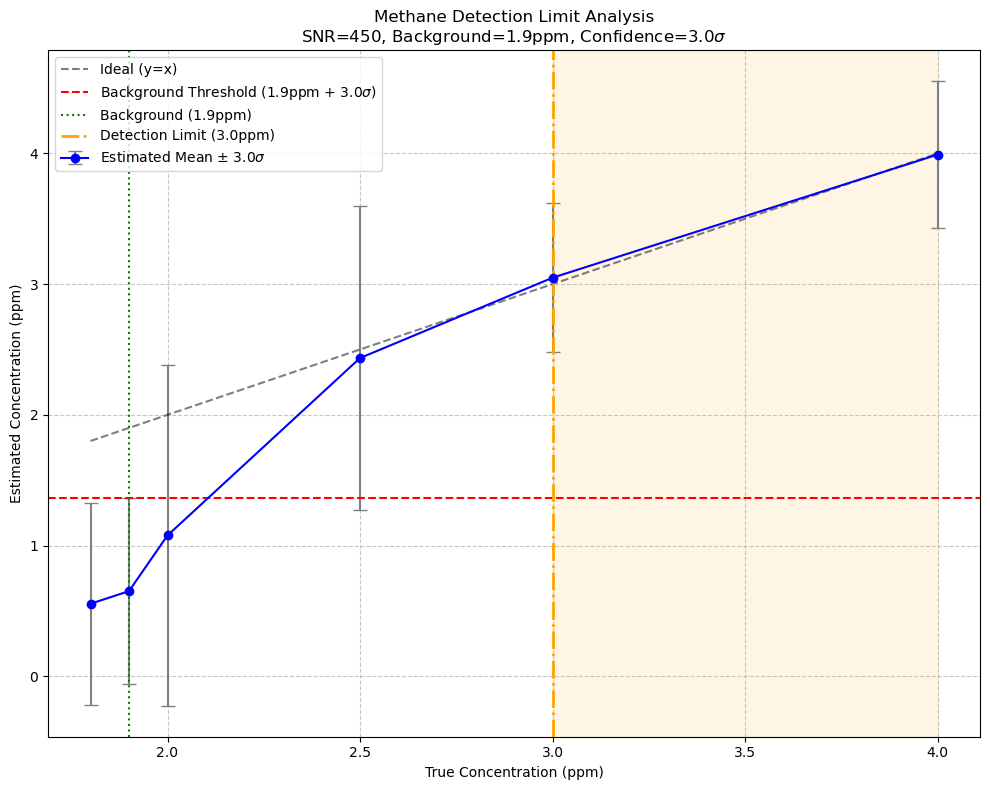

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import re
from tqdm import tqdm

# =========================================================
# 1. 設定パラメータ
# =========================================================
# ファイルパス (Windowsパス用に r"..." を使用)
LUT_FILE = r"E:\tools\thesis\16genkai\lutn.csv"
SPECTRA_FILE = r"E:\refit\all_roi_spectra.csv"
INSTRUMENT_FILE = r"E:\メタン\2025_HISUI_72_The Permian Basin-論文照合用\HSHL1G_N320W1032_20221030160051_20231127193053\HSHL1G_N320W1032_20221030160051_20231127193053_B.csv"

SNR = 450
TRIALS = 50

# 判定用パラメータ (追加)
BG_CONC = 1.90      # 背景濃度 (この濃度の推定ばらつきを基準とする)
SIGMA_K = 3.0       # 判定基準シグマ係数 (3.0なら99.7%信頼区間で分離判定)

# ---------------------------------------------------------
# 濃度設定
# ---------------------------------------------------------

# ① 正解データ（辞書/参照用）として使う濃度リスト
RETRIEVAL_USE_LEVELS = [
    1.50, 1.75, 2.00, 2.50, 3.50, 4.00, 4.50, 4.75, 5.00, 5.25, 5.50, 
    6.00, 6.50, 7.00, 7.50, 8.00, 8.50, 9.00, 9.50, 10.00, 10.50, 11.00, 
    11.50, 12.00, 12.50, 13.00, 13.50, 14.00, 14.50, 15.00, 15.50, 16.00, 
    17.00, 18.00, 19.00, 20.00, 21.00, 22.00, 23.00, 24.00, 25.00, 30.00, 
    35.00, 40.00, 45.00, 50.00, 55.00, 70.00, 75.00, 100.00, 150.00, 
    200.00, 250.00, 300.00, 400.00, 500.00, 700.00, 1000.00
]

# ② 問題データ（テスト用）として使う濃度リスト
#    ※背景濃度(1.90)を含める必要があります
TEST_PROBLEM_LEVELS = [1.80, 1.90, 2.00, 2.50, 3.00, 4.00]

# ---------------------------------------------------------

TARGET_PIXEL_IDX = 0 
TARGET_WAVE_RANGE = (2200, 2400) # 2300nm帯

# =========================================================
# 2. 汎用・計算関数
# =========================================================

def load_lut_and_levels(filepath):
    """LUTファイルを読み込み、データと濃度レベルを返す"""
    df = pd.read_csv(filepath)
    try:
        # 1列目は波長、2列目以降が濃度
        levels = df.columns[1:].astype(float).to_numpy()
    except ValueError:
        raise ValueError("LUT header must be numeric concentration values.")
        
    data = df.to_numpy().T.astype(float)
    data[1:, :] = data[1:, :] * 100 # スケーリング
    return data, levels

def extract_lut_subset(data, all_levels, wanted_levels):
    subset_indices = [0] # 波長列
    valid_levels = []
    
    for level in wanted_levels:
        matches = np.where(np.isclose(all_levels, level))[0]
        if len(matches) > 0:
            subset_indices.append(matches[0] + 1)
            valid_levels.append(level)
            
    if len(subset_indices) <= 1:
        raise ValueError("No valid levels found for retrieval dictionary!")

    subset_data = data[subset_indices, :]
    return subset_data, np.array(valid_levels)

def parse_wavelengths(columns):
    waves = []
    cols_in_range = []
    for col in columns:
        match = re.search(r'wave_([\d\.]+)nm', col)
        if match:
            w = float(match.group(1))
            if TARGET_WAVE_RANGE[0] <= w <= TARGET_WAVE_RANGE[1]:
                waves.append(w)
                cols_in_range.append(col)
    return np.array(waves), cols_in_range

def instrumental_function(data, sigma, mu):
    wavelengths = data[0, :]
    out = np.zeros_like(data)
    out[0, :] = wavelengths
    sigma = max(sigma, 1e-6)
    
    dx = np.mean(np.diff(wavelengths))
    radius = int(4 * sigma / dx)
    kernel_x = np.arange(-radius, radius + 1) * dx
    kernel = np.exp(-(kernel_x - mu)**2 / (2 * sigma**2))
    kernel /= np.sum(kernel)
    
    for i in range(1, data.shape[0]):
        out[i, :] = np.convolve(data[i, :], kernel, mode='same')
    return out

def estimated_by_ch4(data, c, levels):
    if c <= levels[0]: return data[1, :].tolist()
    if c >= levels[-1]: return data[-1, :].tolist()
    
    idx_exact = np.where(np.isclose(levels, c))[0]
    if len(idx_exact) > 0:
        return data[idx_exact[0] + 1, :].tolist()

    idx = np.searchsorted(levels, c)
    c_lower, c_upper = levels[idx - 1], levels[idx]
    r = (c - c_lower) / (c_upper - c_lower)
    return ((1 - r) * data[idx, :] + r * data[idx + 1, :]).tolist()

def forward_model(lut_data, lut_levels, target_waves, sigma, mu, a, b, c, k):
    lut_conv = instrumental_function(lut_data, sigma, mu)
    lut_waves = lut_conv[0, :]
    spec_lut = estimated_by_ch4(lut_conv, c, lut_levels)
    spec_resampled = np.interp(target_waves, lut_waves, spec_lut)
    refl = a + b * target_waves
    refl = np.maximum(refl, 1e-9)
    return spec_resampled * refl + k

def residuals(params, lut_data, lut_levels, target_waves, obs_spec):
    sigma, mu, a, b, c, k = params
    if sigma < 0.1: sigma = 0.1
    if c < 0: c = 0
    est_spec = forward_model(lut_data, lut_levels, target_waves, sigma, mu, a, b, c, k)
    return obs_spec - est_spec

# =========================================================
# 3. メイン処理
# =========================================================
print("--- Loading Data ---")

# LUT読み込み
try:
    data_lut_full, levels_full = load_lut_and_levels(LUT_FILE)
    print(f"Full LUT Loaded: {data_lut_full.shape}")
except Exception as e:
    print(f"Error loading LUT: {e}")
    exit()

# リトリーバル用辞書作成
try:
    data_lut_retrieval, levels_retrieval = extract_lut_subset(data_lut_full, levels_full, RETRIEVAL_USE_LEVELS)
except Exception as e:
    print(f"Error creating subset: {e}")
    exit()

# テストレベル確認
valid_test_levels = []
for c in TEST_PROBLEM_LEVELS:
    if np.any(np.isclose(levels_full, c)):
        valid_test_levels.append(c)
    else:
        print(f"Warning: Test level {c} not in LUT file. Skipping.")

if not valid_test_levels:
    print("Error: No valid test levels found.")
    exit()

# Sigma & Params 推定
try:
    df_inst = pd.read_csv(INSTRUMENT_FILE)
    df_swir = df_inst[(df_inst['CenterWavelengthNanometer'] >= TARGET_WAVE_RANGE[0]) & 
                      (df_inst['CenterWavelengthNanometer'] <= TARGET_WAVE_RANGE[1])]
    mean_fwhm = df_swir['FullWidthAtHalfMaximumNanometer'].mean()
    true_sigma = mean_fwhm / 2.355
except:
    true_sigma = 5.6

try:
    df_spectra = pd.read_csv(SPECTRA_FILE)
    target_waves, target_cols = parse_wavelengths(df_spectra.columns)
    pixel_data = df_spectra.iloc[TARGET_PIXEL_IDX][target_cols].values.astype(float)
    true_k = np.min(pixel_data)
    mean_wave = np.mean(target_waves)
    
    lut_waves = data_lut_retrieval[0, :]
    base_conc = levels_retrieval[0]
    spec_base = estimated_by_ch4(data_lut_retrieval, base_conc, levels_retrieval)
    spec_base_res = np.interp(target_waves, lut_waves, spec_base)
    max_lut_val = np.max(spec_base_res)
    true_b = (np.max(pixel_data) - true_k) / (mean_wave * max_lut_val)
    print(f"True Params -> k: {true_k:.4f}, b: {true_b:.4e}, Sigma: {true_sigma:.4f}")
except Exception as e:
    print(f"Error reading pixel data: {e}")
    exit()

# =========================================================
# 4. シミュレーション実行
# =========================================================
print(f"\n--- Starting Simulation (SNR={SNR}) ---")
results_true = []
results_est = []

margin = 50
lut_mask_ret = (data_lut_retrieval[0, :] >= TARGET_WAVE_RANGE[0]-margin) & (data_lut_retrieval[0, :] <= TARGET_WAVE_RANGE[1]+margin)
lut_crop_retrieval = data_lut_retrieval[:, lut_mask_ret]

lut_mask_full = (data_lut_full[0, :] >= TARGET_WAVE_RANGE[0]-margin) & (data_lut_full[0, :] <= TARGET_WAVE_RANGE[1]+margin)
lut_crop_full = data_lut_full[:, lut_mask_full]

for true_c in tqdm(valid_test_levels, desc="Simulating"):
    true_spec = forward_model(
        lut_crop_full, levels_full, target_waves, 
        true_sigma, 0.0, 0.0, true_b, true_c, true_k
    )
    
    for _ in range(TRIALS):
        if np.mean(true_spec) == 0:
            noise_std = 1e-9
        else:
            noise_std = true_spec / SNR
            
        noise = np.random.normal(0, noise_std, size=len(true_spec))
        obs_spec = true_spec + noise
        
        init_k = np.min(obs_spec)
        init_b = (np.max(obs_spec) - init_k) / (mean_wave * max_lut_val)
        
        # 初期値: テスト範囲の真ん中あたり
        x0 = [6.5, 0.0, 0.0, init_b, 3.0, init_k]
        
        try:
            res = least_squares(
                residuals, x0, 
                args=(lut_crop_retrieval, levels_retrieval, target_waves, obs_spec),
                method='lm'
            )
            results_true.append(true_c)
            results_est.append(res.x[4])
        except:
            pass

# =========================================================
# 5. 統計解析と判定の可視化 (追加・更新部分)
# =========================================================
# 結果をDataFrameに集計
df_res = pd.DataFrame({
    "True_Conc": results_true,
    "Estimated": results_est
})

# 濃度ごとの統計量 (平均, 標準偏差) を計算
stats = df_res.groupby("True_Conc")["Estimated"].agg(["mean", "std"]).reset_index()
# 信頼区間 (Mean ± 3Sigma)
stats["Lower_Bound"] = stats["mean"] - SIGMA_K * stats["std"]
stats["Upper_Bound"] = stats["mean"] + SIGMA_K * stats["std"]

print("\n--- Simulation Statistics ---")
print(stats)

# 背景濃度の基準値を計算
bg_upper_limit = None
if BG_CONC in stats["True_Conc"].values:
    bg_row = stats[stats["True_Conc"] == BG_CONC].iloc[0]
    # 背景の上限閾値 = 背景平均 + 3*背景標準偏差
    bg_upper_limit = bg_row["mean"] + SIGMA_K * bg_row["std"]
    
    print(f"\n[Background Reference]")
    print(f"  Background Conc: {BG_CONC} ppm")
    print(f"  Mean Est:        {bg_row['mean']:.4f} ppm")
    print(f"  Std Dev:         {bg_row['std']:.4f} ppm")
    print(f"  Separation Threshold ({SIGMA_K}sigma): {bg_upper_limit:.4f} ppm")
else:
    print(f"\nWarning: Background concentration {BG_CONC} ppm was not simulated. Cannot determine detection limit.")

# 検出限界の判定
detection_limit = None
if bg_upper_limit is not None:
    # 背景より濃度が高いものを候補とする
    candidates = stats[stats["True_Conc"] > BG_CONC]
    for _, row in candidates.iterrows():
        # 判定ロジック: 「異常濃度の推定分布の下限」 > 「背景分布の上限」
        if row["Lower_Bound"] > bg_upper_limit:
            detection_limit = row["True_Conc"]
            print(f"\n[Detection Limit Found]")
            print(f"  Concentration: {detection_limit} ppm")
            print(f"  Range: {row['Lower_Bound']:.4f} - {row['Upper_Bound']:.4f}")
            print(f"  (Separated from background limit: {bg_upper_limit:.4f})")
            break

# グラフ描画
plt.figure(figsize=(10, 8))

# エラーバー付き散布図 (Mean ± 3Sigma)
plt.errorbar(
    stats["True_Conc"], stats["mean"], 
    yerr=SIGMA_K * stats["std"], 
    fmt='o-', capsize=5, color='blue', ecolor='gray', 
    label=f'Estimated Mean ± {SIGMA_K}$\sigma$'
)

# 理想線 (y=x)
min_c, max_c = stats["True_Conc"].min(), stats["True_Conc"].max()
plt.plot([min_c, max_c], [min_c, max_c], 'k--', alpha=0.5, label='Ideal (y=x)')

# 背景基準線 (赤の点線)
if bg_upper_limit is not None:
    plt.axhline(y=bg_upper_limit, color='red', linestyle='--', label=f'Background Threshold ({BG_CONC}ppm + {SIGMA_K}$\sigma$)')
    plt.axvline(x=BG_CONC, color='green', linestyle=':', label=f'Background ({BG_CONC}ppm)')

# 検出限界 (オレンジの線)
if detection_limit is not None:
    plt.axvline(x=detection_limit, color='orange', linestyle='-.', linewidth=2, label=f'Detection Limit ({detection_limit}ppm)')
    # 検出可能領域を塗りつぶし
    plt.axvspan(detection_limit, max_c, color='orange', alpha=0.1)

plt.title(f"Methane Detection Limit Analysis\nSNR={SNR}, Background={BG_CONC}ppm, Confidence={SIGMA_K}$\sigma$")
plt.xlabel("True Concentration (ppm)")
plt.ylabel("Estimated Concentration (ppm)")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.7)

# 濃度範囲が広い場合はログスケール
if max_c / (min_c + 1e-9) > 50:
    plt.xscale('log')
    plt.yscale('log')

plt.tight_layout()
plt.show()